In [ ]:
pip install ucimlrepo

**Load datasets**

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from google.colab import drive
drive.mount('/content/drive')

# Fetch dataset
bcwd = fetch_ucirepo(id=17)

# Extract features and target
X_bcwd = bcwd.data.features
y_bcwd = bcwd.data.targets

# Convert target to 0 and 1
label_encoder_bcwd = LabelEncoder()
y_bcwd = label_encoder_bcwd.fit_transform(y_bcwd).ravel()

# Ensure data is in pandas DataFrame format
if not isinstance(X_bcwd, pd.DataFrame):
    X_bcwd = pd.DataFrame(X_bcwd)
if not isinstance(y_bcwd, pd.Series):
    if isinstance(y_bcwd, pd.DataFrame):
        y_bcwd = y_bcwd.iloc[:, 0]  # Extract the first column if y is a DataFrame
    else:
        y_bcwd = pd.Series(y_bcwd)

# Combine features and target into one DataFrame
bcwd = pd.concat([X_bcwd, y_bcwd.rename("target")], axis=1)





# Fetch dataset
bcwo = fetch_ucirepo(id=15)

# Extract features and target
X_bcwo = bcwo.data.features
y_bcwo = bcwo.data.targets

# Convert target to 0 and 1
label_encoder_bcwo = LabelEncoder()
y_bcwo = label_encoder_bcwo.fit_transform(y_bcwo).ravel()

# Ensure data is in pandas DataFrame format
if not isinstance(X_bcwo, pd.DataFrame):
    X_bcwo = pd.DataFrame(X_bcwo)
if not isinstance(y_bcwo, pd.Series):
    if isinstance(y_bcwo, pd.DataFrame):
        y_bcwo = y_bcwo.iloc[:, 0]  # Extract the first column if y is a DataFrame
    else:
        y_bcwo = pd.Series(y_bcwo)

# Combine features and target into one DataFrame
bcwo = pd.concat([X_bcwo, y_bcwo.rename("target")], axis=1)




file_path = '/content/bcancerfeat.csv'
bct= pd.read_csv(file_path)

bct = bct[bct['target'] != 3]

X_bct = bct.drop(columns=['target'])

y_bct = bct['target']

label_encoder_bct = LabelEncoder()

y_bct = label_encoder_bct.fit_transform(y_bct)

bct['target'] = y_bct


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Logistic Regression with all sampling approaches**

Best model for BCWD is Instance Hardness Threshold
Best model for BCWO is Instance Hardness Threshold
Best model for BCT is Instance Hardness Threshold
   Dataset                                Method  Accuracy  Sensitivity  \
0     BCWD           Instance Hardness Threshold    0.9911       0.9857   
1     BCWD                     Cluster Centroids    0.9670       0.9580   
2     BCWD                             SVM SMOTE    0.9748       0.9804   
3     BCWD   SMOTE + Instance Hardness Threshold    0.9790       0.9775   
4     BCWD   SMOTE + Neighbourhood Cleaning Rule    0.9889       0.9847   
5     BCWD    Random Oversampling with Smoothing    0.9832       0.9804   
6     BCWD                         No Resampling    0.9771       0.9623   
7     BCWD  No Resampling + No Feature Selection    0.9842       0.9714   
8     BCWO           Instance Hardness Threshold    0.9984       0.9958   
9     BCWO                     Cluster Centroids    0.9564       0.9585   
10    BCWO             

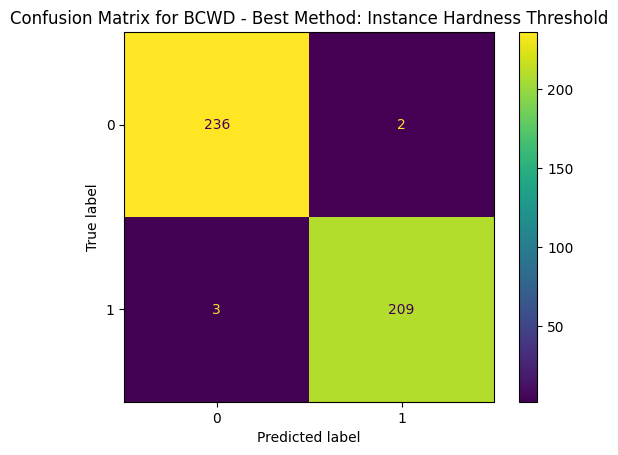

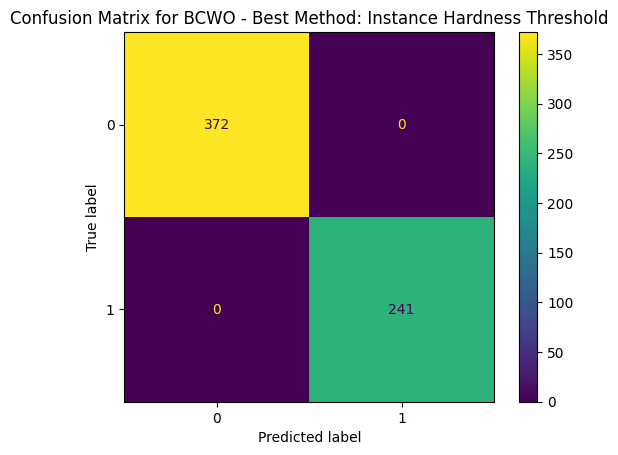

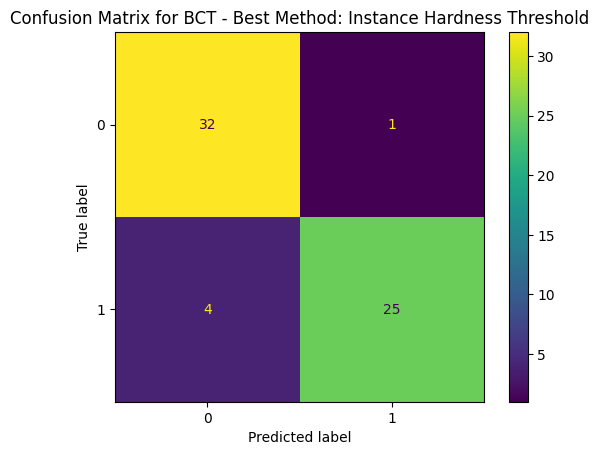

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.under_sampling import InstanceHardnessThreshold, ClusterCentroids
from imblearn.over_sampling import SVMSMOTE, SMOTE, RandomOverSampler
from imblearn.under_sampling import NeighbourhoodCleaningRule
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def ensure_dataframe(X, y):
    """
    Ensure that the features and target are in pandas DataFrame and Series formats respectively.

    Parameters:
    X (array-like): The feature set.
    y (array-like): The target labels.

    Returns:
    X (pd.DataFrame): Feature set as a DataFrame.
    y (pd.Series): Target labels as a Series.
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    if not isinstance(y, pd.Series):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]  # Extract the first column if y is a DataFrame
        else:
            y = pd.Series(y)
    return X, y

X_bcwd, y_bcwd = ensure_dataframe(X_bcwd, y_bcwd)
X_bcwo, y_bcwo = ensure_dataframe(X_bcwo, y_bcwo)

# Impute missing values for bcwo using KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_bcwo = pd.DataFrame(imputer.fit_transform(X_bcwo), columns=X_bcwo.columns)

def specificity_score(y_true, y_pred):
    """
    Calculate the specificity score, defined as the ratio of true negatives to the sum of true negatives and false positives.

    Parameters:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.

    Returns:
    float: Specificity score.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

def geometric_mean_score(y_true, y_pred):
    """
    Calculate the geometric mean of sensitivity and specificity.

    Parameters:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.

    Returns:
    float: Geometric mean score.
    """
    sensitivity = recall_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

# Custom scorers for specificity, G-Mean, and F1 score
specificity = make_scorer(specificity_score)
g_mean = make_scorer(geometric_mean_score, greater_is_better=True)
f1 = make_scorer(f1_score)

def smote_instance_hardness_threshold(X, y):
    """
    Apply SMOTE followed by Instance Hardness Thresholding.

    Parameters:
    X (pd.DataFrame): The feature set.
    y (pd.Series): The target labels.

    Returns:
    X_res (pd.DataFrame): Resampled feature set.
    y_res (pd.Series): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101, k_neighbors=5)
    iht = InstanceHardnessThreshold(sampling_strategy='all', random_state=101)
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = iht.fit_resample(X_res, y_res)
    return X_res, y_res

def smote_neighbourhood_cleaning_rule(X, y):
    """
    Apply SMOTE followed by Neighbourhood Cleaning Rule.

    Parameters:
    X (pd.DataFrame): The feature set.
    y (pd.Series): The target labels.

    Returns:
    X_res (pd.DataFrame): Resampled feature set.
    y_res (pd.Series): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101)
    ncr = NeighbourhoodCleaningRule(sampling_strategy='all')
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = ncr.fit_resample(X_res, y_res)
    return X_res, y_res

def build_and_evaluate_model(X, y, sampling_method=None, feature_selection=True):
    """
    Build and evaluate a logistic regression model with optional Lasso feature selection and resampling using a pipeline.

    Parameters:
    X (pd.DataFrame): The feature set.
    y (pd.Series): The target labels.
    sampling_method (callable, optional): A resampling method to be applied before model training.
    feature_selection (bool, optional): Whether to apply Lasso for feature selection. Defaults to True.

    Returns:
    cv_results (dict): Cross-validation results.
    best_params (dict): Best parameters found by GridSearchCV.
    best_estimator (sklearn estimator): Best estimator found by GridSearchCV.
    X_resampled (pd.DataFrame): Resampled feature set.
    y_resampled (pd.Series): Resampled target labels.
    num_features_selected (int): Number of features selected by Lasso, or total features if no feature selection.
    """
    scaler = StandardScaler()

    # Logistic Regression with Lasso for feature selection
    if feature_selection:
        lasso = SelectFromModel(Lasso(alpha=0.01))
        pipeline = Pipeline([
            ('scaler', scaler),
            ('lasso', lasso),
            ('log_reg', LogisticRegression(solver='liblinear'))
        ])
        param_grid = {
            'lasso__estimator__alpha': [0.01, 0.1, 1, 10, 100],
            'log_reg__C': [0.01, 0.1, 1, 10, 100],
            'log_reg__penalty': ['l1', 'l2']
        }
    else:
        pipeline = Pipeline([
            ('scaler', scaler),
            ('log_reg', LogisticRegression(solver='liblinear'))
        ])
        param_grid = {
            'log_reg__C': [0.01, 0.1, 1, 10, 100],
            'log_reg__penalty': ['l1', 'l2']
        }

    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)

    # GridSearchCV with Stratified K-Fold
    grid_search = GridSearchCV(pipeline, param_grid, cv=stratified_kfold, scoring=g_mean)

    if sampling_method:
        X_resampled, y_resampled = sampling_method(X, y) if callable(sampling_method) else sampling_method.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search.fit(X_resampled, y_resampled)
    best_params = grid_search.best_params_

    # Cross-validation on the resampled data
    cv_results = cross_validate(grid_search.best_estimator_, X_resampled, y_resampled, cv=stratified_kfold, scoring={
        'accuracy': 'accuracy',
        'sensitivity': 'recall',
        'specificity': specificity,
        'g_mean': g_mean,
        'f1': f1
    }, n_jobs=2, return_train_score=False)

    num_features_selected = np.sum(grid_search.best_estimator_.named_steps['lasso'].get_support()) if feature_selection else X.shape[1]

    return cv_results, best_params, grid_search.best_estimator_, X_resampled, y_resampled, num_features_selected

sampling_methods = {
    'Instance Hardness Threshold': InstanceHardnessThreshold(random_state=101),
    'Cluster Centroids': ClusterCentroids(random_state=101),
    'SVM SMOTE': SVMSMOTE(random_state=101),
    'SMOTE + Instance Hardness Threshold': smote_instance_hardness_threshold,
    'SMOTE + Neighbourhood Cleaning Rule': smote_neighbourhood_cleaning_rule,
    'Random Oversampling with Smoothing': RandomOverSampler(sampling_strategy='auto', random_state=101)
}

datasets = {
    'BCWD': (X_bcwd, y_bcwd),
    'BCWO': (X_bcwo, y_bcwo),
    'BCT': (X_bct, y_bct)
}

results = []
best_results = []
best_models = {}

for dataset_name, (X, y) in datasets.items():
    best_gmean = 0
    best_cv_results = None
    best_best_params = None
    best_method = None

    # Evaluate all sampling methods + feature selection
    for method_name, sampling_method in sampling_methods.items():
        cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(X, y, sampling_method)

        result = {
            'Dataset': dataset_name,
            'Method': method_name,
            'Accuracy': np.mean(cv_results['test_accuracy']),
            'Sensitivity': np.mean(cv_results['test_sensitivity']),
            'Specificity': np.mean(cv_results['test_specificity']),
            'G-Mean': np.mean(cv_results['test_g_mean']),
            'F1 Score': np.mean(cv_results['test_f1']),
            'Best Params': best_params,
            'Num Features Selected': num_features_selected
        }
        results.append(result)

        if np.mean(cv_results['test_g_mean']) > best_gmean:
            best_gmean = np.mean(cv_results['test_g_mean'])
            best_cv_results = cv_results
            best_best_params = best_params
            best_method = method_name
            best_models[dataset_name] = (best_estimator, X_resampled, y_resampled, best_method)

    if best_cv_results is not None:
        print(f"Best model for {dataset_name} is {best_method}")
        result = {
            'Dataset': dataset_name,
            'Accuracy': np.mean(best_cv_results['test_accuracy']),
            'Sensitivity': np.mean(best_cv_results['test_sensitivity']),
            'Specificity': np.mean(best_cv_results['test_specificity']),
            'G-Mean': np.mean(best_cv_results['test_g_mean']),
            'F1 Score': np.mean(best_cv_results['test_f1']),
            'Best Params': best_best_params,
            'Num Features Selected': num_features_selected
        }
        best_results.append(result)

    # Evaluate with No Resampling
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(X, y)
    result = {
        'Dataset': dataset_name,
        'Method': 'No Resampling',
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Sensitivity': np.mean(cv_results['test_sensitivity']),
        'Specificity': np.mean(cv_results['test_specificity']),
        'G-Mean': np.mean(cv_results['test_g_mean']),
        'F1 Score': np.mean(cv_results['test_f1']),
        'Best Params': best_params,
        'Num Features Selected': num_features_selected
    }
    results.append(result)

    # Evaluate with No Resampling + No Feature Selection
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(X, y, feature_selection=False)
    result = {
        'Dataset': dataset_name,
        'Method': 'No Resampling + No Feature Selection',
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Sensitivity': np.mean(cv_results['test_sensitivity']),
        'Specificity': np.mean(cv_results['test_specificity']),
        'G-Mean': np.mean(cv_results['test_g_mean']),
        'F1 Score': np.mean(cv_results['test_f1']),
        'Best Params': best_params,
        'Num Features Selected': num_features_selected
    }
    results.append(result)


results_lr = pd.DataFrame(results)
best_results_lr = pd.DataFrame(best_results)

print(results_lr.round(4))
print(best_results_lr.round(4))


results_lr.to_csv('results_lr.csv', index=False)

# Plot confusion matrix for the best models
for dataset_name, (model, X_resampled, y_resampled, best_method) in best_models.items():
    y_pred = model.predict(X_resampled)
    cm = confusion_matrix(y_resampled, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix for {dataset_name} - Best Method: {best_method}")
    plt.show()


**KNN with all sampling approaches**

   Dataset                                Method  Accuracy  Sensitivity  \
0     BCWD           Instance Hardness Threshold    0.9867       0.9719   
1     BCWD                     Cluster Centroids    0.9719       0.9675   
2     BCWD                             SVM SMOTE    0.9734       0.9666   
3     BCWD   SMOTE + Instance Hardness Threshold    0.9818       0.9776   
4     BCWD   SMOTE + Neighbourhood Cleaning Rule    0.9889       0.9878   
5     BCWD    Random Oversampling with Smoothing    0.9832       0.9805   
6     BCWD                         No Resampling    0.9771       0.9526   
7     BCWD  No Resampling + No Feature Selection    0.9771       0.9526   
8     BCWO           Instance Hardness Threshold    0.9967       0.9917   
9     BCWO                     Cluster Centroids    0.9605       0.9750   
10    BCWO                             SVM SMOTE    0.9847       1.0000   
11    BCWO   SMOTE + Instance Hardness Threshold    0.9825       0.9935   
12    BCWO   SMOTE + Neig

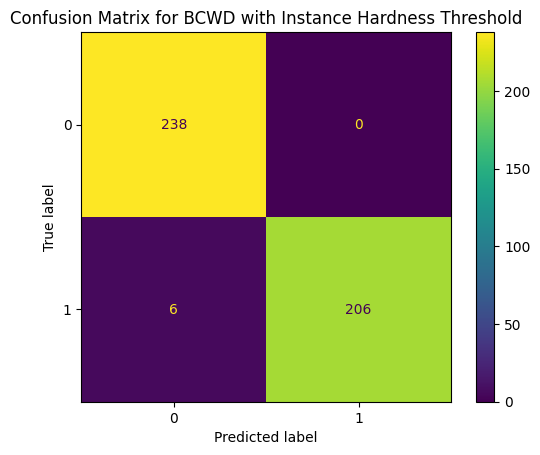

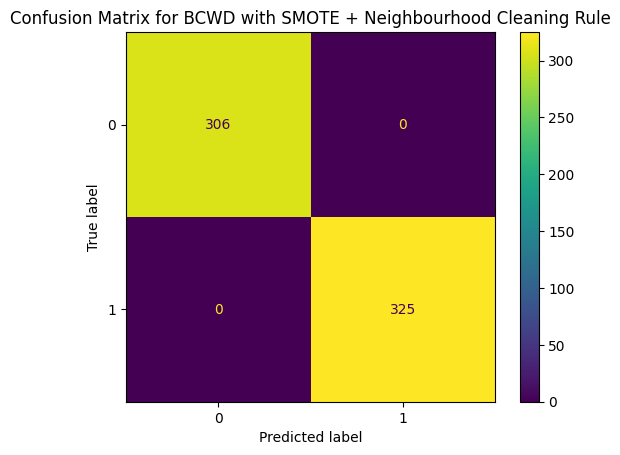

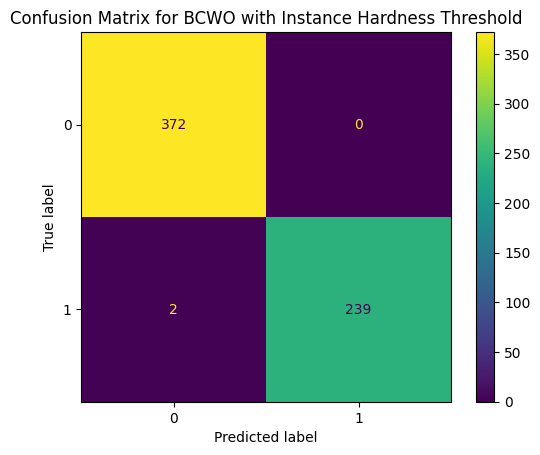

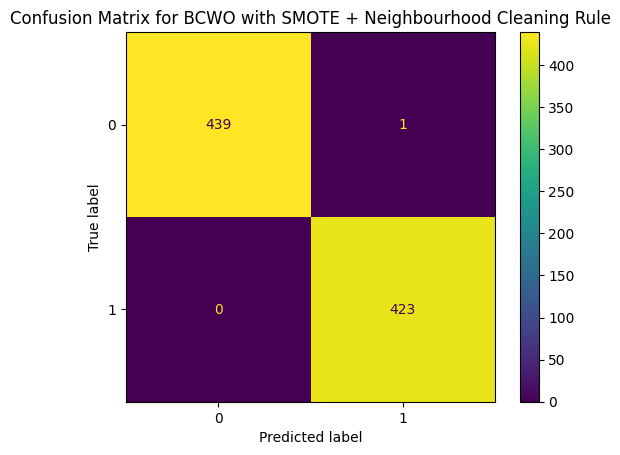

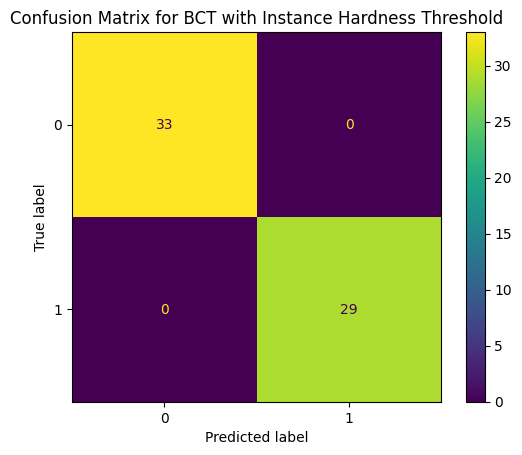

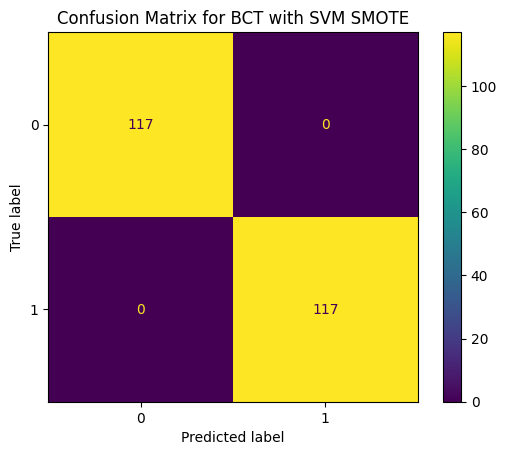

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import InstanceHardnessThreshold, ClusterCentroids
from imblearn.over_sampling import SVMSMOTE, SMOTE, RandomOverSampler
from imblearn.under_sampling import NeighbourhoodCleaningRule
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def ensure_dataframe(X, y):
    """
    Ensure that the input features (X) and target (y) are in pandas DataFrame or Series format.

    Parameters:
    X (array-like or DataFrame): Input feature data.
    y (array-like, DataFrame, or Series): Target labels.

    Returns:
    X (DataFrame): Feature data in DataFrame format.
    y (Series): Target data in Series format.
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    if not isinstance(y, pd.Series):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]  # Extract the first column if y is a DataFrame
        else:
            y = pd.Series(y)
    return X, y

# Convert datasets to DataFrame format
X_bcwd, y_bcwd = ensure_dataframe(X_bcwd, y_bcwd)
X_bcwo, y_bcwo = ensure_dataframe(X_bcwo, y_bcwo)

# Impute missing values for the BCWO dataset using KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_bcwo = pd.DataFrame(imputer.fit_transform(X_bcwo), columns=X_bcwo.columns)

def specificity_score(y_true, y_pred):
    """
    Calculate the specificity (true negative rate) from the confusion matrix.

    Parameters:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.

    Returns:
    float: Specificity score.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

def geometric_mean_score(y_true, y_pred):
    """
    Calculate the geometric mean of sensitivity (recall) and specificity.

    Parameters:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.

    Returns:
    float: Geometric mean score.
    """
    sensitivity = recall_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

# Custom scorers for specificity, G-Mean, and F1 score
specificity = make_scorer(specificity_score)
g_mean = make_scorer(geometric_mean_score, greater_is_better=True)
f1 = make_scorer(f1_score)

def smote_instance_hardness_threshold(X, y):
    """
    Apply SMOTE followed by Instance Hardness Threshold for resampling.

    Parameters:
    X (DataFrame or ndarray): Input features.
    y (Series or ndarray): Target labels.

    Returns:
    X_res (DataFrame or ndarray): Resampled input features.
    y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101, k_neighbors=5)
    iht = InstanceHardnessThreshold(sampling_strategy='all', random_state=101)
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = iht.fit_resample(X_res, y_res)
    return X_res, y_res

def smote_neighbourhood_cleaning_rule(X, y):
    """
    Apply SMOTE followed by Neighbourhood Cleaning Rule for resampling.

    Parameters:
    X (DataFrame or ndarray): Input features.
    y (Series or ndarray): Target labels.

    Returns:
    X_res (DataFrame or ndarray): Resampled input features.
    y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101)
    ncr = NeighbourhoodCleaningRule(sampling_strategy='all')
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = ncr.fit_resample(X_res, y_res)
    return X_res, y_res

# Define n_features values to test for each dataset
n_features_values = {
    'BCWD': [10, 15, 20, 25, 30],
    'BCWO': [5, 6, 7, 8, 9],
    'BCT': [14, 20, 26, 32, 38]
}

def build_and_evaluate_model(X, y, dataset_name, sampling_method=None, feature_selection=True):
    """
    Build and evaluate a KNN model with optional feature selection and resampling using GridSearchCV and cross-validation.

    Parameters:
    X (DataFrame or ndarray): Input features.
    y (Series or ndarray): Target labels.
    dataset_name (str): Name of the dataset to determine the range of features for selection.
    sampling_method (function or None): Resampling method to handle class imbalance.
    feature_selection (bool): Whether to apply feature selection (RFE) in the pipeline.

    Returns:
    cv_results (dict): Cross-validation results.
    best_params (dict): Best hyperparameters found by GridSearchCV.
    best_estimator (Pipeline): The best model pipeline.
    X_resampled (DataFrame or ndarray): Resampled input features.
    y_resampled (Series or ndarray): Resampled target labels.
    num_features_selected (int): Number of features selected by RFE, or total features if no feature selection.
    """
    scaler = StandardScaler()
    knn_model = KNeighborsClassifier()

    if feature_selection:
        rf = RandomForestClassifier(random_state=101)
        rfe = RFE(estimator=rf)
        pipeline = Pipeline([
            ('scaler', scaler),
            ('rfe', rfe),
            ('knn', knn_model)
        ])
        param_grid = {
            'rfe__n_features_to_select': n_features_values[dataset_name],
            'knn__weights': ['uniform', 'distance'],
            'knn__metric': ['euclidean', 'manhattan'],
            'knn__n_neighbors': [3, 5, 7]
        }
    else:
        pipeline = Pipeline([
            ('scaler', scaler),
            ('knn', knn_model)
        ])
        param_grid = {
            'knn__weights': ['uniform', 'distance'],
            'knn__metric': ['euclidean', 'manhattan'],
            'knn__n_neighbors': [3, 5, 7]
        }

    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)
    grid_search = GridSearchCV(pipeline, param_grid, cv=stratified_kfold, scoring=g_mean, n_jobs=2)

    if sampling_method:
        X_resampled, y_resampled = sampling_method(X, y) if callable(sampling_method) else sampling_method.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search.fit(X_resampled, y_resampled)
    best_params = grid_search.best_params_

    cv_results = cross_validate(grid_search.best_estimator_, X_resampled, y_resampled, cv=stratified_kfold, scoring={
        'accuracy': 'accuracy',
        'sensitivity': 'recall',
        'specificity': specificity,
        'g_mean': g_mean,
        'f1': f1
    }, n_jobs=2, return_train_score=False)

    num_features_selected = grid_search.best_estimator_.named_steps['rfe'].n_features_ if feature_selection else len(X.columns)

    return cv_results, best_params, grid_search.best_estimator_, X_resampled, y_resampled, num_features_selected


sampling_methods = {
    'Instance Hardness Threshold': InstanceHardnessThreshold(random_state=101),
    'Cluster Centroids': ClusterCentroids(random_state=101),
    'SVM SMOTE': SVMSMOTE(random_state=101),
    'SMOTE + Instance Hardness Threshold': smote_instance_hardness_threshold,
    'SMOTE + Neighbourhood Cleaning Rule': smote_neighbourhood_cleaning_rule,
    'Random Oversampling with Smoothing': RandomOverSampler(sampling_strategy='auto', random_state=101)
}

# Define datasets
datasets = {
    'BCWD': (X_bcwd, y_bcwd),
    'BCWO': (X_bcwo, y_bcwo),
    'BCT': (X_bct, y_bct)
}

results = []
best_models = {}

for dataset_name, (X, y) in datasets.items():
    best_gmean = 0

    # Evaluate all sampling methods + feature selection
    for method_name, sampling_method in sampling_methods.items():
        cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(X, y, dataset_name, sampling_method)

        result = {
            'Dataset': dataset_name,
            'Method': method_name,
            'Accuracy': np.mean(cv_results['test_accuracy']),
            'Sensitivity': np.mean(cv_results['test_sensitivity']),
            'Specificity': np.mean(cv_results['test_specificity']),
            'G-Mean': np.mean(cv_results['test_g_mean']),
            'F1 Score': np.mean(cv_results['test_f1']),
            'Best Params': best_params,
            'Num Features Selected': num_features_selected
        }
        results.append(result)

        if np.mean(cv_results['test_g_mean']) > best_gmean:
            best_gmean = np.mean(cv_results['test_g_mean'])
            best_models[(dataset_name, method_name)] = (best_estimator, X_resampled, y_resampled, method_name)

    # Evaluate with No Resampling
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(X, y, dataset_name)
    result = {
        'Dataset': dataset_name,
        'Method': 'No Resampling',
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Sensitivity': np.mean(cv_results['test_sensitivity']),
        'Specificity': np.mean(cv_results['test_specificity']),
        'G-Mean': np.mean(cv_results['test_g_mean']),
        'F1 Score': np.mean(cv_results['test_f1']),
        'Best Params': best_params,
        'Num Features Selected': num_features_selected
    }
    results.append(result)

    # Evaluate with No Resampling + No Feature Selection
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(X, y, dataset_name, feature_selection=False)
    result = {
        'Dataset': dataset_name,
        'Method': 'No Resampling + No Feature Selection',
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Sensitivity': np.mean(cv_results['test_sensitivity']),
        'Specificity': np.mean(cv_results['test_specificity']),
        'G-Mean': np.mean(cv_results['test_g_mean']),
        'F1 Score': np.mean(cv_results['test_f1']),
        'Best Params': best_params,
        'Num Features Selected': num_features_selected
    }
    results.append(result)

# Save the results to a CSV file
results_knn = pd.DataFrame(results).round(4)
results_knn.to_csv('results_knn.csv', index=False)
print(results_knn)

# Plot confusion matrix for the best models
for (dataset_name, method_name), (model, X_resampled, y_resampled, method_name) in best_models.items():
    y_pred = model.predict(X_resampled)
    cm = confusion_matrix(y_resampled, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix for {dataset_name} with {method_name}')
    plt.show()


**SVC with all sampling approaches**

Best model for BCWD is SMOTE + Neighbourhood Cleaning Rule with 10 features
Best model for BCWO is Instance Hardness Threshold with 6 features
Best model for BCT is Random Oversampling with Smoothing with 32 features
   Dataset                                Method  n_features  Accuracy  \
0     BCWD           Instance Hardness Threshold          10    0.9933   
1     BCWD                     Cluster Centroids          30    0.9788   
2     BCWD                             SVM SMOTE          20    0.9818   
3     BCWD   SMOTE + Instance Hardness Threshold          30    0.9846   
4     BCWD   SMOTE + Neighbourhood Cleaning Rule          10    0.9952   
5     BCWD    Random Oversampling with Smoothing          30    0.9874   
6     BCWD                         No Resampling          30    0.9824   
7     BCWD  No Resampling + No Feature Selection          30    0.9824   
8     BCWO           Instance Hardness Threshold           6    0.9984   
9     BCWO                     Cluster Cent

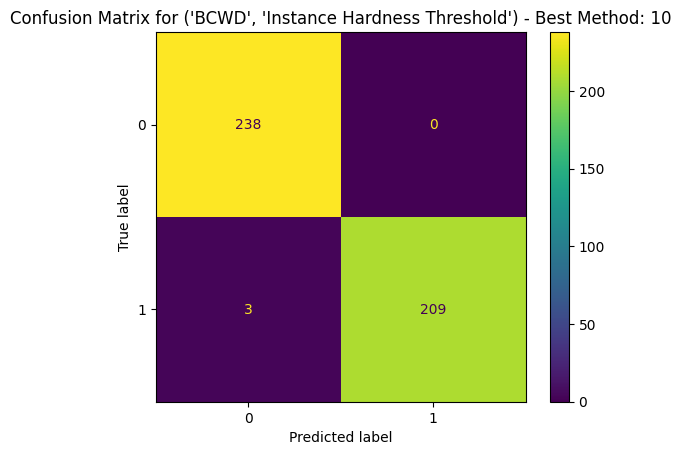

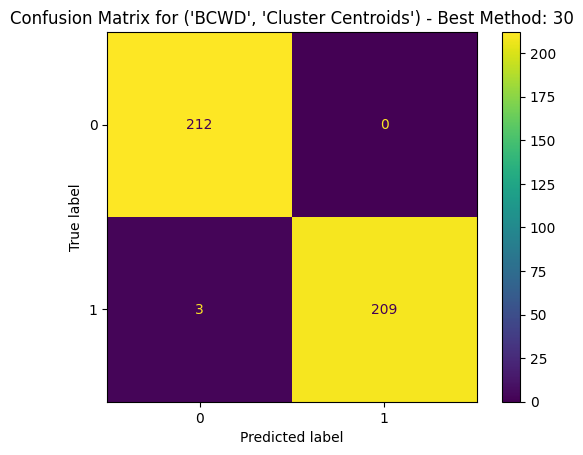

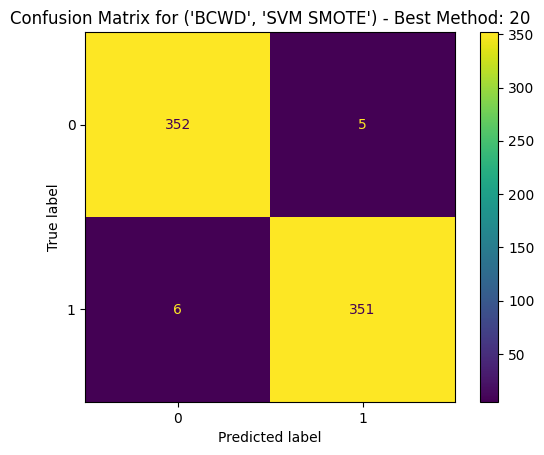

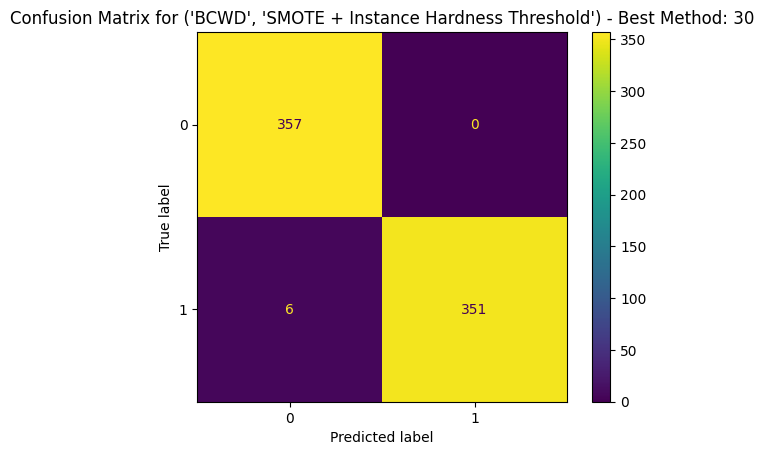

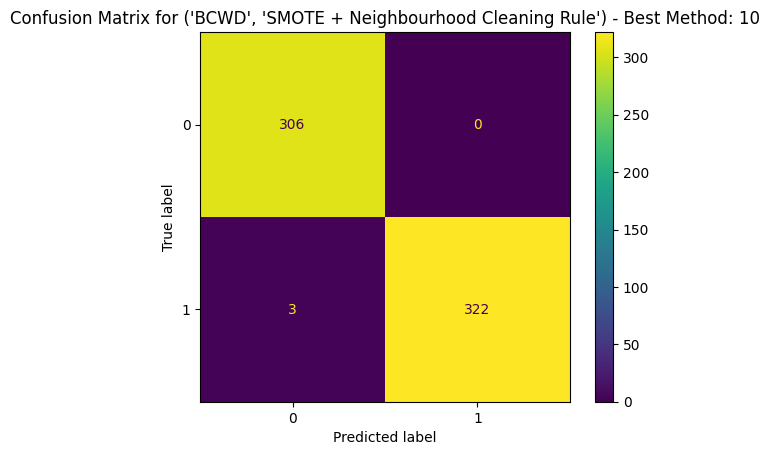

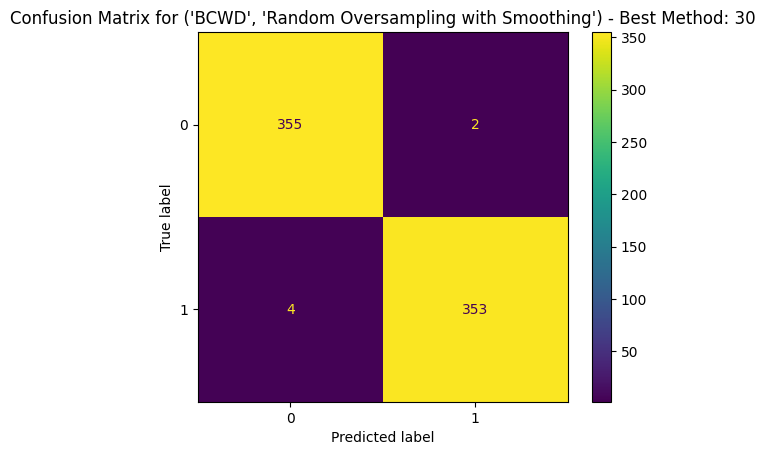

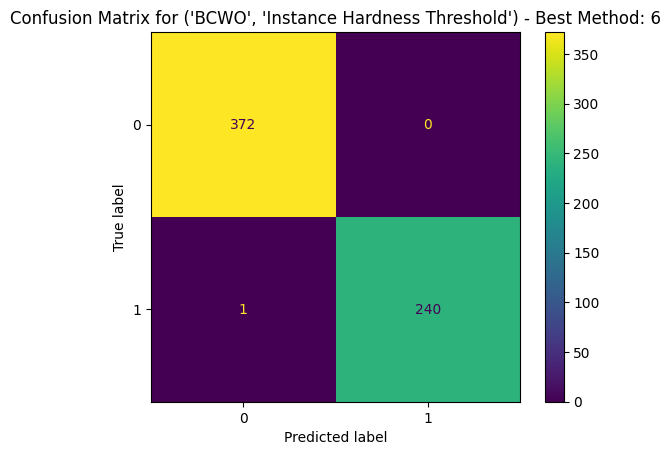

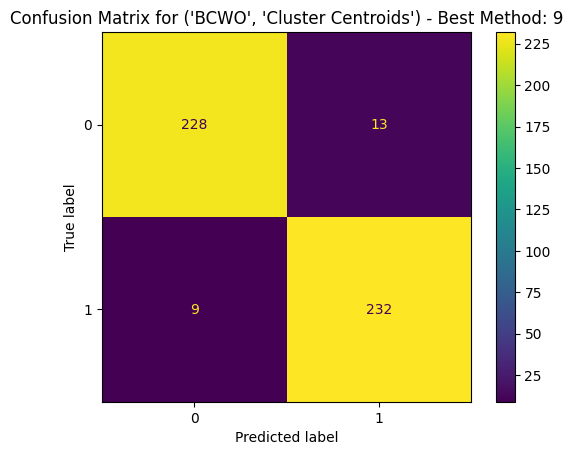

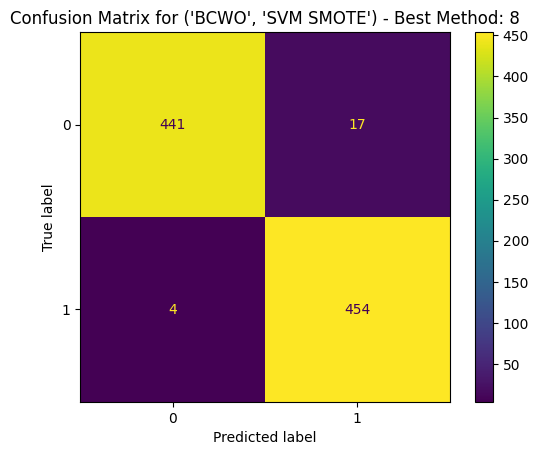

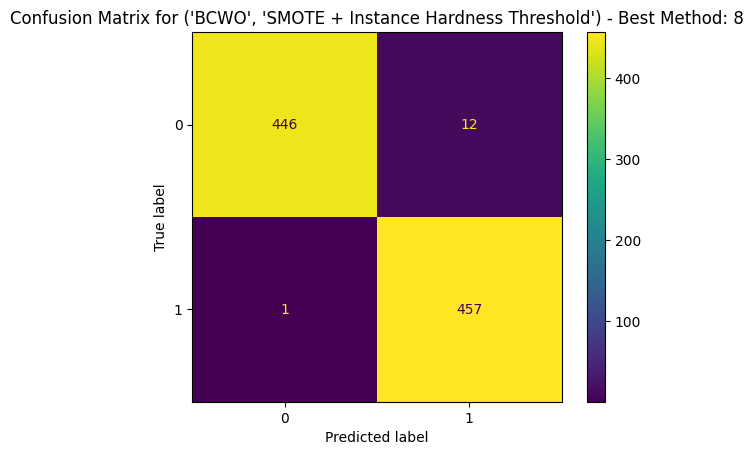

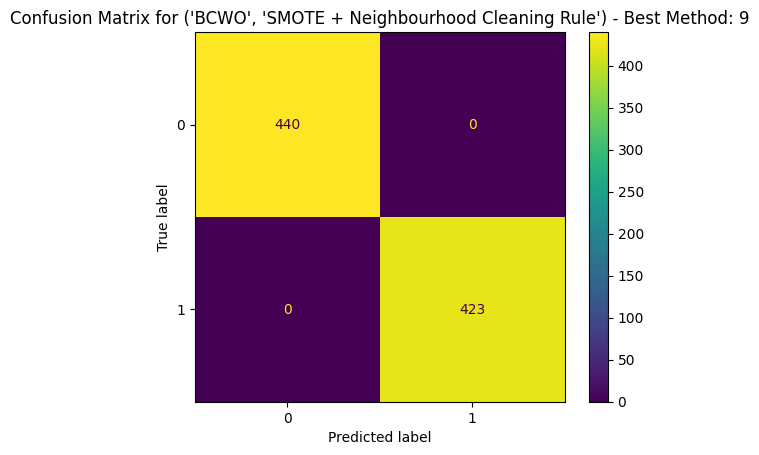

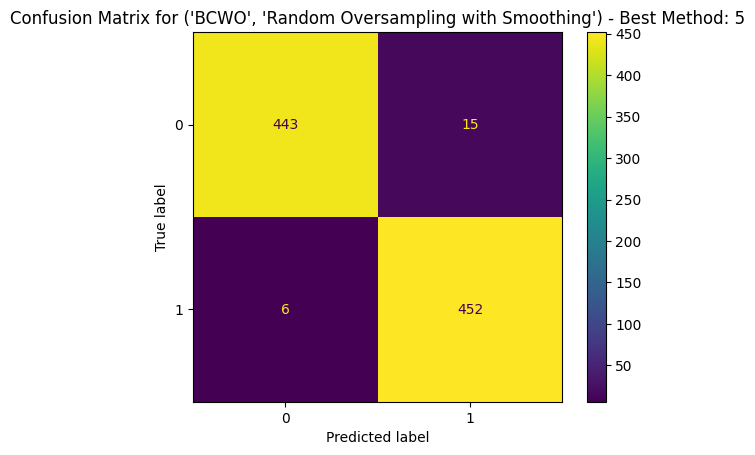

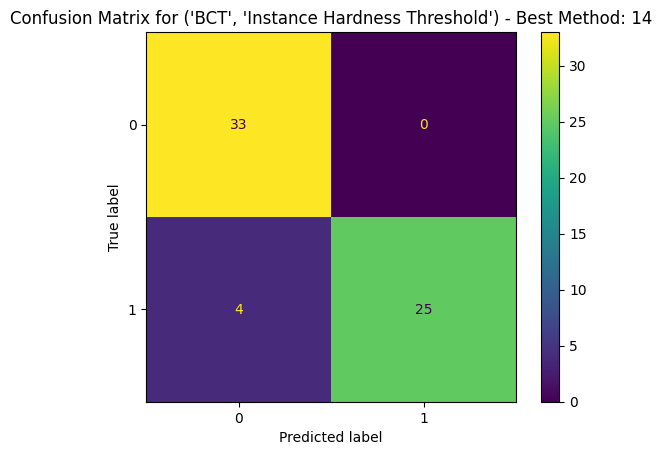

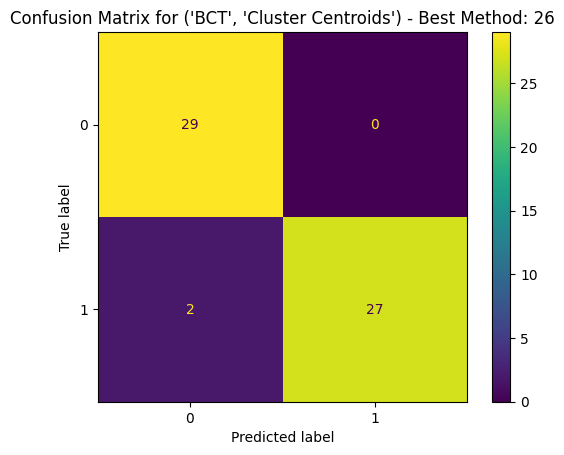

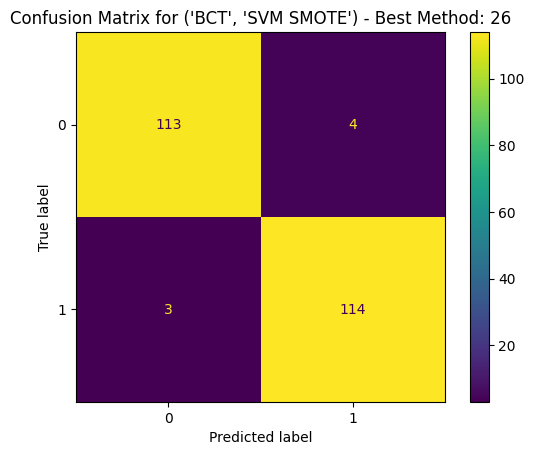

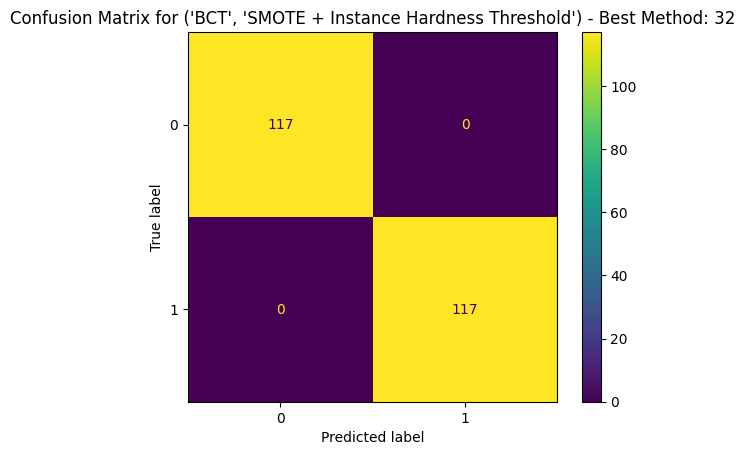

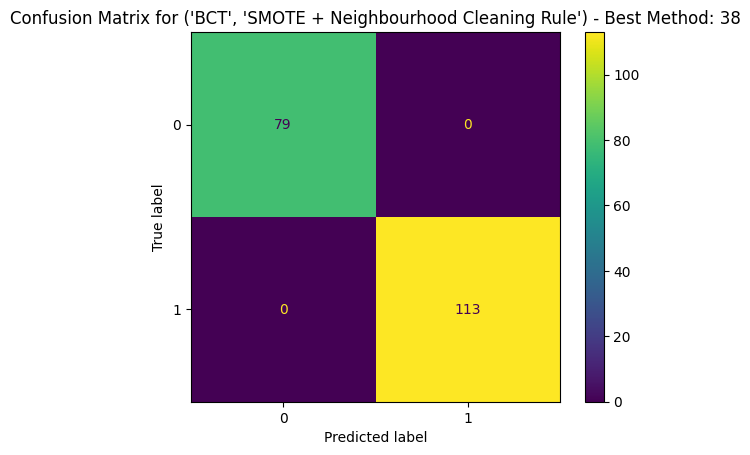

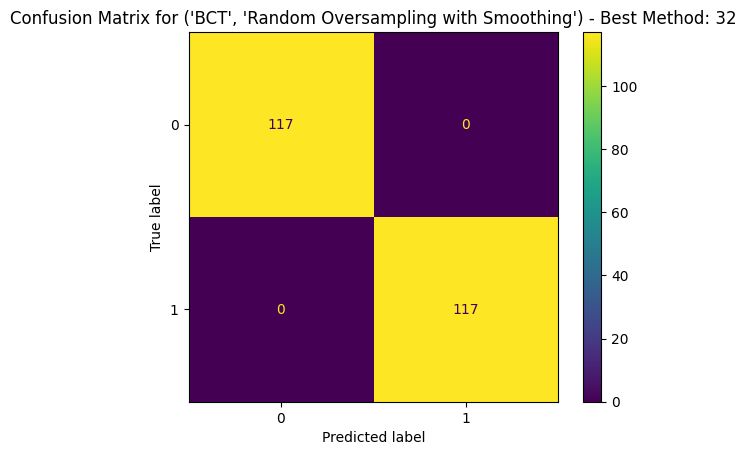

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.under_sampling import InstanceHardnessThreshold, ClusterCentroids
from imblearn.over_sampling import SVMSMOTE, SMOTE, RandomOverSampler
from imblearn.under_sampling import NeighbourhoodCleaningRule
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def ensure_dataframe(X, y):
    """
    Ensure that the input features (X) and target (y) are in pandas DataFrame or Series format.

    Parameters:
        X (array-like or DataFrame): Input feature data.
        y (array-like, DataFrame, or Series): Target labels.

    Returns:
        X (DataFrame): Feature data in DataFrame format.
        y (Series): Target data in Series format.
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    if not isinstance(y, pd.Series):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]  # Extract the first column if y is a DataFrame
        else:
            y = pd.Series(y)
    return X, y

def specificity_score(y_true, y_pred):
    """
    Calculate specificity (true negative rate) from the confusion matrix.

    Parameters:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        float: Specificity score.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

def geometric_mean_score(y_true, y_pred):
    """
    Calculate the geometric mean of sensitivity (recall) and specificity.

    Parameters:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        float: Geometric mean score.
    """
    sensitivity = recall_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

# Create custom scoring functions for use in model evaluation
specificity = make_scorer(specificity_score)
g_mean = make_scorer(geometric_mean_score, greater_is_better=True)
f1 = make_scorer(f1_score)

def smote_instance_hardness_threshold(X, y):
    """
    Apply SMOTE followed by Instance Hardness Threshold for resampling.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.

    Returns:
        X_res (DataFrame or ndarray): Resampled input features.
        y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101, k_neighbors=5)
    iht = InstanceHardnessThreshold(sampling_strategy='all', random_state=101)
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = iht.fit_resample(X_res, y_res)
    return X_res, y_res

def smote_neighbourhood_cleaning_rule(X, y):
    """
    Apply SMOTE followed by Neighbourhood Cleaning Rule for resampling.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.

    Returns:
        X_res (DataFrame or ndarray): Resampled input features.
        y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101)
    ncr = NeighbourhoodCleaningRule(sampling_strategy='all')
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = ncr.fit_resample(X_res, y_res)
    return X_res, y_res

# Define the number of features to select during feature selection for each dataset
n_features_values = {
    'BCWD': [10, 15, 20, 25, 30],
    'BCWO': [5, 6, 7, 8, 9],
    'BCT': [14, 20, 26, 32, 38]
}

def build_and_evaluate_model(X, y, n_features=None, sampling_method=None, feature_selection=True):
    """
    Build and evaluate an SVM model using a pipeline with scaling, optional feature selection, and classification.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.
        n_features (int, optional): Number of features to select using RFE. If None, no feature selection is applied.
        sampling_method (function or None): Resampling method to handle class imbalance.
        feature_selection (bool): Whether to perform feature selection or not.

    Returns:
        cv_results (dict): Cross-validation results.
        best_params (dict): Best hyperparameters found by GridSearchCV.
        best_estimator (Pipeline): The best model pipeline.
        X_resampled (DataFrame or ndarray): Resampled input features.
        y_resampled (Series or ndarray): Resampled target labels.
        num_features_selected (int): Number of features selected by RFE or total features if no feature selection.
    """
    scaler = StandardScaler()


    svm_model = SVC(kernel='linear')

    # If feature selection is enabled, use RFE with the specified number of features
    if feature_selection and n_features is not None:
        rfe = RFE(estimator=svm_model, n_features_to_select=n_features)
        pipeline_steps = [('scaler', scaler), ('rfe', rfe), ('svm', svm_model)]
    else:
        pipeline_steps = [('scaler', scaler), ('svm', svm_model)]

    pipeline = Pipeline(pipeline_steps)


    param_grid = {
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['linear', 'rbf']
    }

    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)


    grid_search = GridSearchCV(pipeline, param_grid, cv=stratified_kfold, scoring=g_mean)

    # Apply resampling method if provided
    if sampling_method:
        if callable(sampling_method):
            X_resampled, y_resampled = sampling_method(X, y)
        else:
            X_resampled, y_resampled = sampling_method.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search.fit(X_resampled, y_resampled)
    best_params = grid_search.best_params_


    cv_results = cross_validate(grid_search.best_estimator_, X_resampled, y_resampled, cv=stratified_kfold, scoring={
        'accuracy': 'accuracy',
        'sensitivity': 'recall',
        'specificity': specificity,
        'g_mean': g_mean,
        'f1': f1
    }, n_jobs=2, return_train_score=False)

    num_features_selected = n_features if feature_selection else X.shape[1]

    return cv_results, best_params, grid_search.best_estimator_, X_resampled, y_resampled, num_features_selected

sampling_methods = {
    'Instance Hardness Threshold': InstanceHardnessThreshold(random_state=101),
    'Cluster Centroids': ClusterCentroids(random_state=101),
    'SVM SMOTE': SVMSMOTE(random_state=101),
    'SMOTE + Instance Hardness Threshold': smote_instance_hardness_threshold,
    'SMOTE + Neighbourhood Cleaning Rule': smote_neighbourhood_cleaning_rule,
    'Random Oversampling with Smoothing': RandomOverSampler(sampling_strategy='auto', random_state=101)
}


datasets = {
    'BCWD': (X_bcwd, y_bcwd),
    'BCWO': (X_bcwo, y_bcwo),
    'BCT': (X_bct, y_bct)
}

results = []
best_models = {}

for dataset_name, (X, y) in datasets.items():
    for method_name, sampling_method in sampling_methods.items():
        best_gmean = 0
        best_cv_results = None
        best_best_params = None
        best_n_features = None

        # Iterate over different numbers of features for the current dataset
        for n_features in n_features_values[dataset_name]:
            cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
                X, y, n_features, sampling_method)

            # Update the best results if the current model has a better G-Mean
            if np.mean(cv_results['test_g_mean']) > best_gmean:
                best_gmean = np.mean(cv_results['test_g_mean'])
                best_cv_results = cv_results
                best_best_params = best_params
                best_n_features = n_features
                best_models[(dataset_name, method_name)] = (best_estimator, X_resampled, y_resampled, best_n_features)

        if best_cv_results is not None:
            result = {
                'Dataset': dataset_name,
                'Method': method_name,
                'n_features': best_n_features,
                'Accuracy': np.mean(best_cv_results['test_accuracy']),
                'Sensitivity': np.mean(best_cv_results['test_sensitivity']),
                'Specificity': np.mean(best_cv_results['test_specificity']),
                'G-Mean': np.mean(best_cv_results['test_g_mean']),
                'F1 Score': np.mean(best_cv_results['test_f1']),
                'Best Params': best_best_params,
                'Num Features Selected': best_n_features
            }
            results.append(result)

    # Evaluate the dataset without any resampling method and select the best feature set
    best_no_resampling_result = None
    best_no_resampling_gmean = 0
    for n_features in n_features_values[dataset_name]:
        cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
            X, y, n_features)

        if np.mean(cv_results['test_g_mean']) > best_no_resampling_gmean:
            best_no_resampling_gmean = np.mean(cv_results['test_g_mean'])
            best_no_resampling_result = {
                'Dataset': dataset_name,
                'Method': 'No Resampling',
                'n_features': num_features_selected,
                'Accuracy': np.mean(cv_results['test_accuracy']),
                'Sensitivity': np.mean(cv_results['test_sensitivity']),
                'Specificity': np.mean(cv_results['test_specificity']),
                'G-Mean': np.mean(cv_results['test_g_mean']),
                'F1 Score': np.mean(cv_results['test_f1']),
                'Best Params': best_params,
                'Num Features Selected': num_features_selected
            }

    if best_no_resampling_result is not None:
        results.append(best_no_resampling_result)

    # Evaluate the dataset without any resampling method and without feature selection (only hyperparameter tuning)
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
        X, y, feature_selection=False)

    result_no_resampling_no_fs = {
        'Dataset': dataset_name,
        'Method': 'No Resampling + No Feature Selection',
        'n_features': num_features_selected,
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Sensitivity': np.mean(cv_results['test_sensitivity']),
        'Specificity': np.mean(cv_results['test_specificity']),
        'G-Mean': np.mean(cv_results['test_g_mean']),
        'F1 Score': np.mean(cv_results['test_f1']),
        'Best Params': best_params,
        'Num Features Selected': num_features_selected
    }
    results.append(result_no_resampling_no_fs)

# Identify the best model for each dataset based on G-Mean
best_dataset_results = []
for dataset_name in datasets.keys():
    dataset_results = [r for r in results if r['Dataset'] == dataset_name]
    best_method_result = max(dataset_results, key=lambda x: x['G-Mean'])
    best_dataset_results.append(best_method_result)

    print(f"Best model for {dataset_name} is {best_method_result['Method']} with {best_method_result['n_features']} features")

# Save and display the results
results_svc = pd.DataFrame(results)
best_results_svc = pd.DataFrame(best_dataset_results)

print(results_svc.round(4))
print(best_results_svc.round(4))

results_svc.to_csv('results_svc.csv', index=False)
best_results_svc.to_csv('best_results_svc.csv', index=False)

# Plot confusion matrix for the best models
for dataset_name, (model, X_resampled, y_resampled, best_method) in best_models.items():
    y_pred = model.predict(X_resampled)
    cm = confusion_matrix(y_resampled, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix for {dataset_name} - Best Method: {best_method}")
    plt.show()


**Random Forest with all sampling approaches**

Best model for BCWD is Instance Hardness Threshold with 21 features
Best model for BCWO is SMOTE + Neighbourhood Cleaning Rule with 8 features
Best model for BCT is Random Oversampling with Smoothing with 16 features
   Dataset                                Method  n_features  Accuracy  \
0     BCWD           Instance Hardness Threshold          21    0.9911   
1     BCWD                     Cluster Centroids          16    0.9530   
2     BCWD                             SVM SMOTE          27    0.9622   
3     BCWD   SMOTE + Instance Hardness Threshold          28    0.9665   
4     BCWD   SMOTE + Neighbourhood Cleaning Rule          28    0.9889   
5     BCWD    Random Oversampling with Smoothing          16    0.9720   
6     BCWD                         No Resampling          15    0.9666   
7     BCWD  No Resampling + No Feature Selection          30    0.9596   
8     BCWO           Instance Hardness Threshold           8    0.9951   
9     BCWO                     Cluster Cent

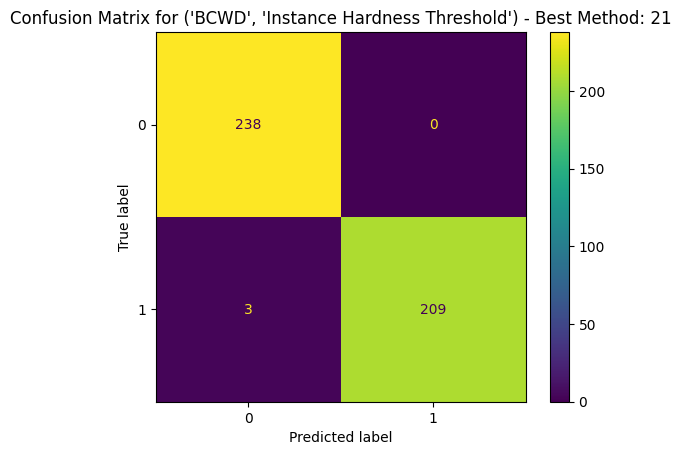

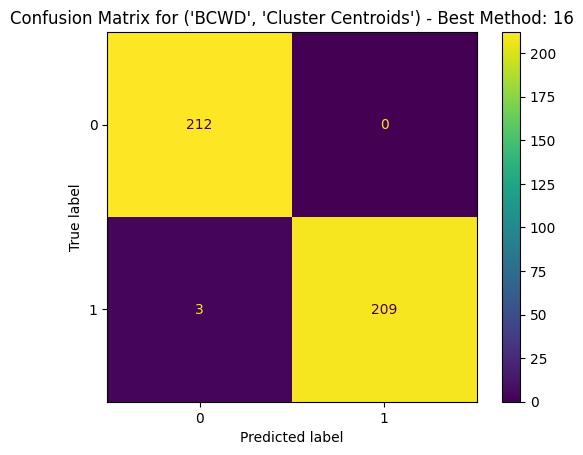

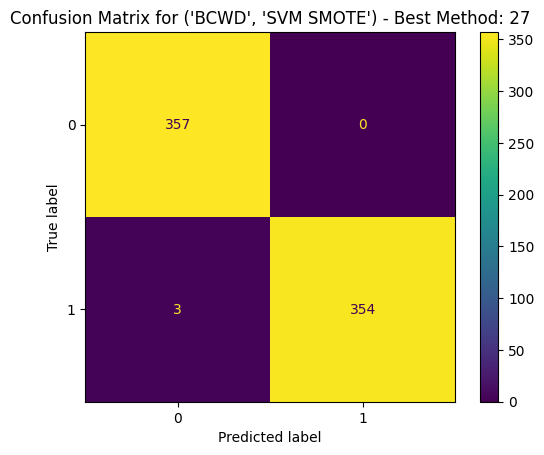

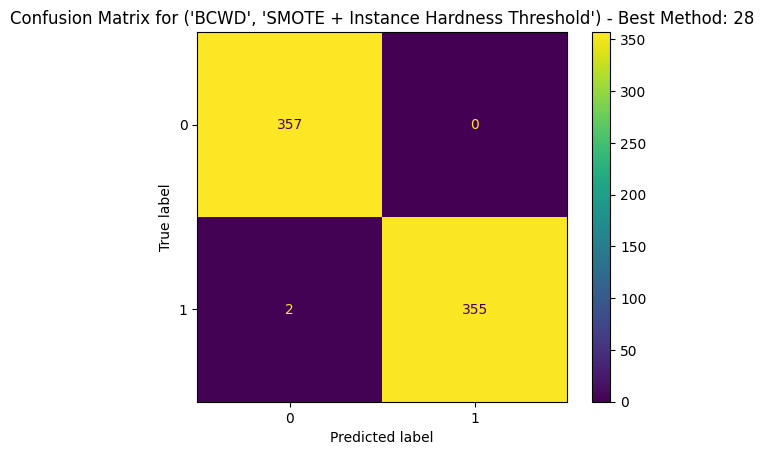

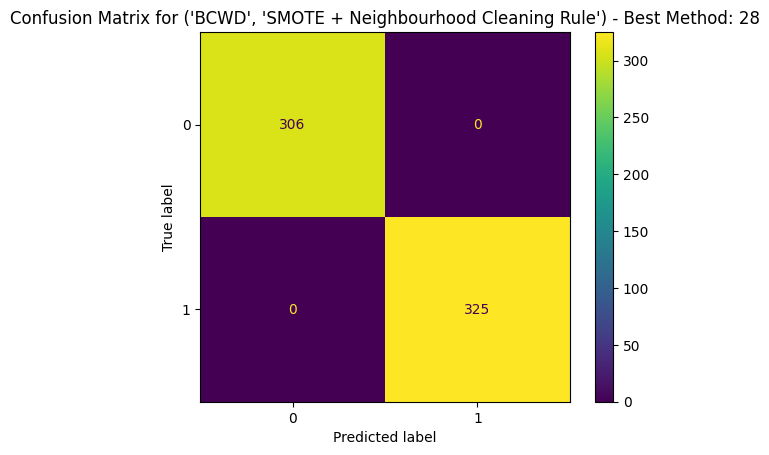

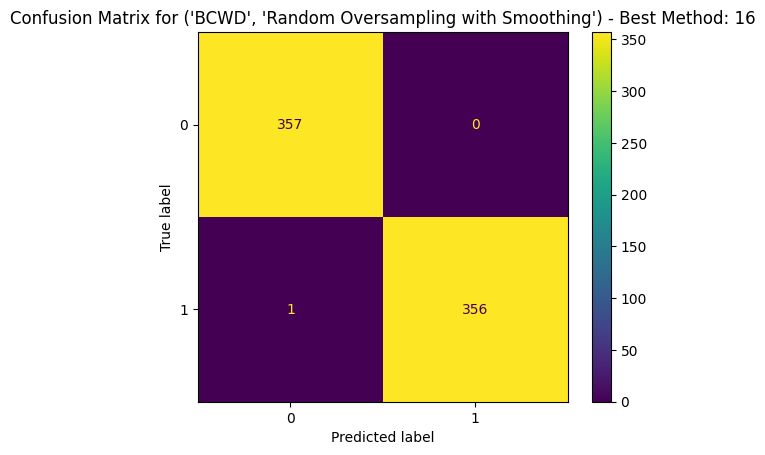

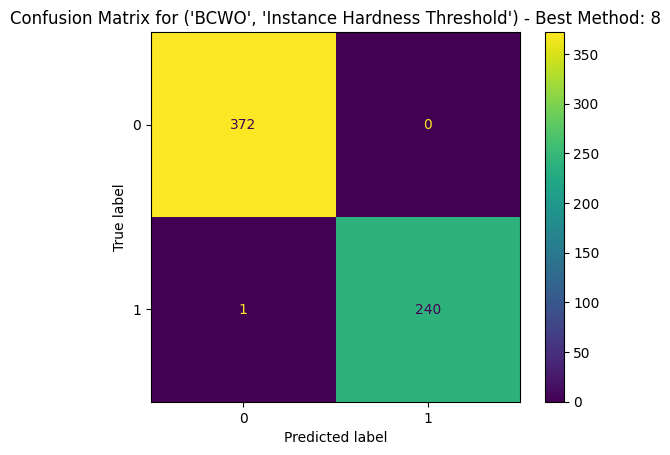

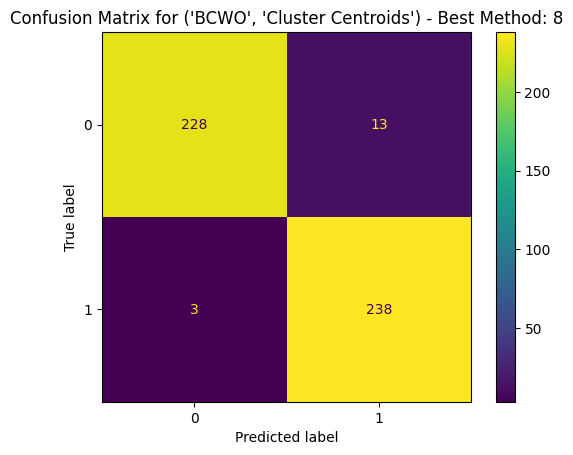

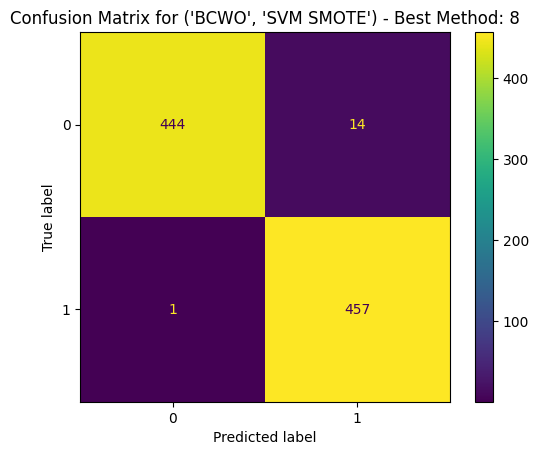

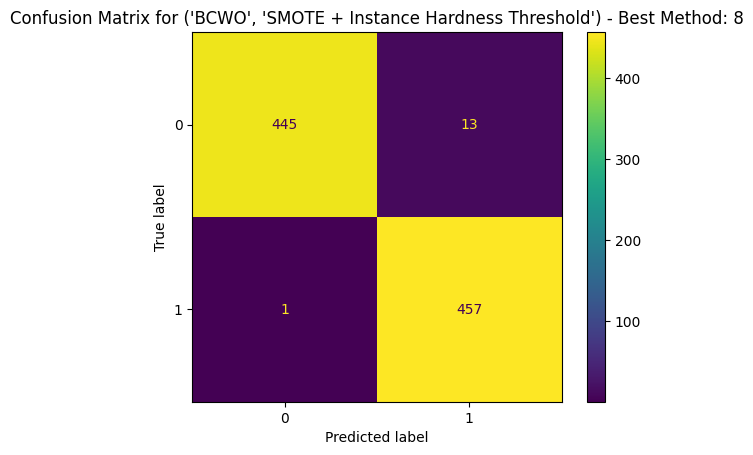

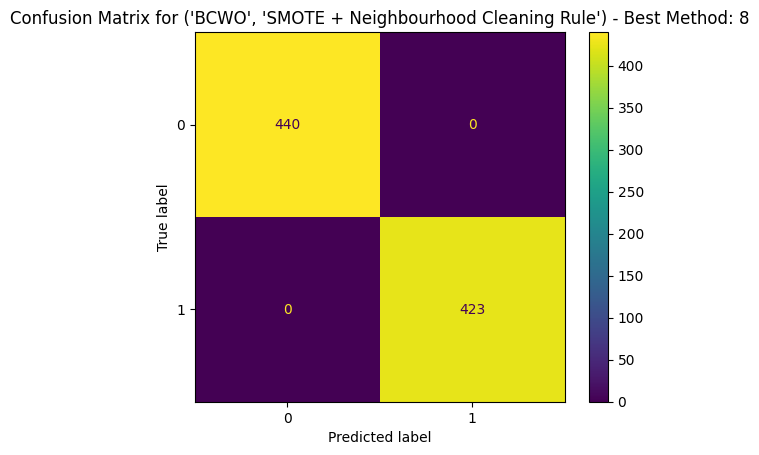

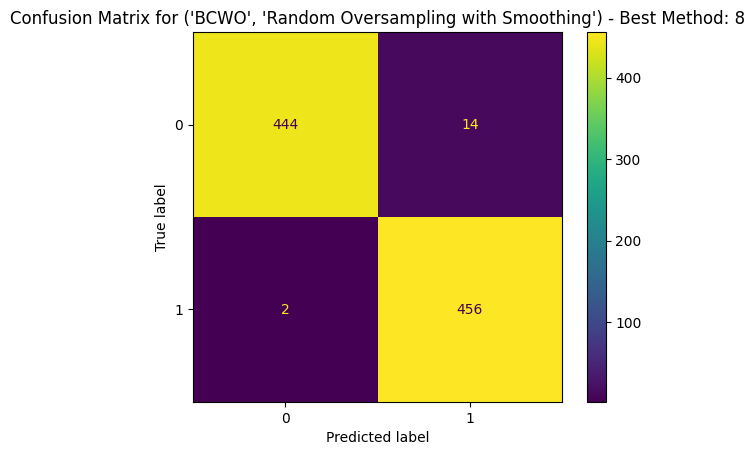

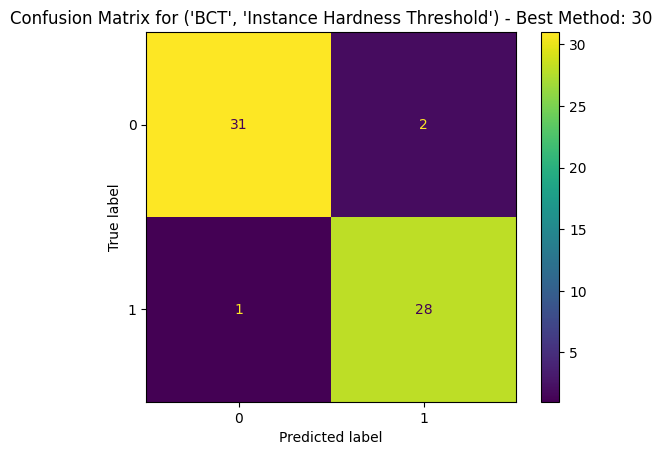

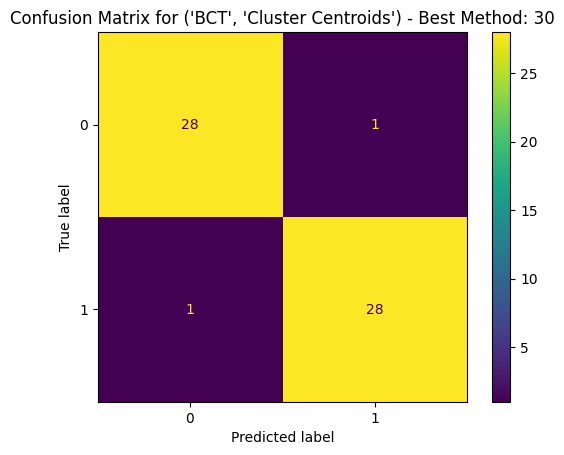

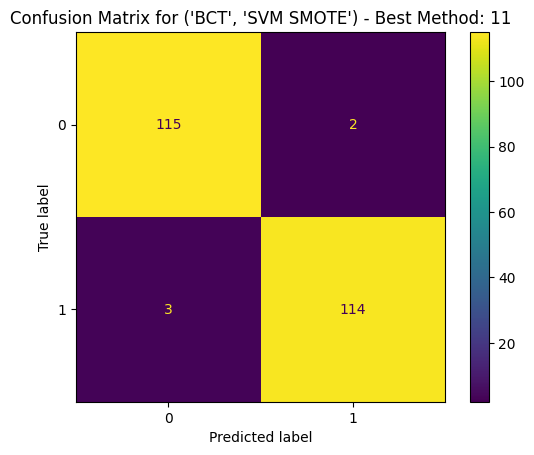

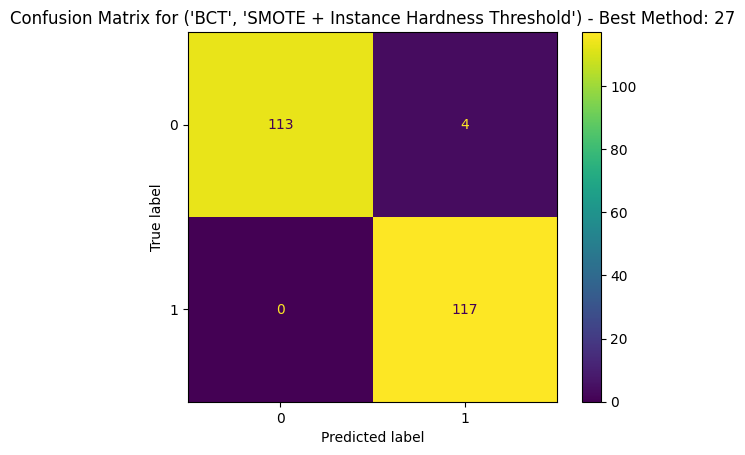

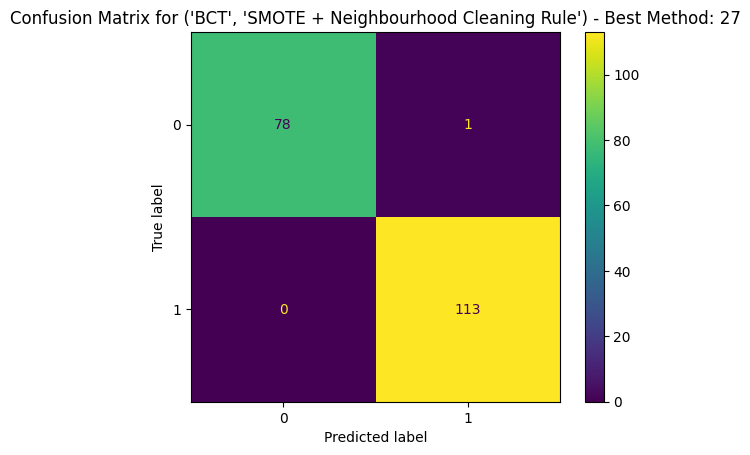

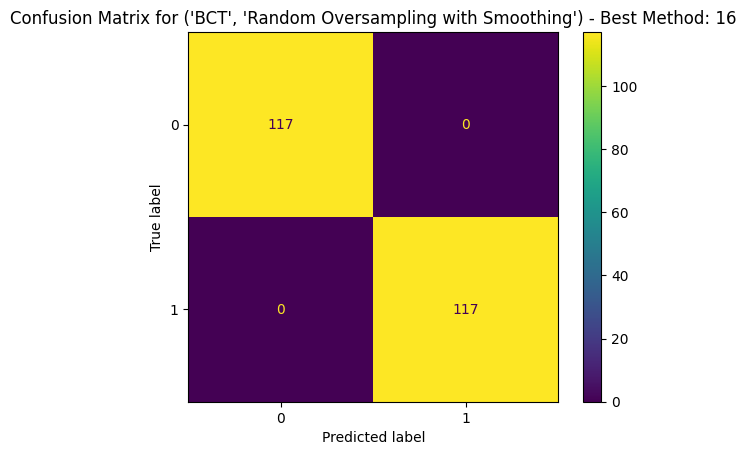

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.under_sampling import InstanceHardnessThreshold, ClusterCentroids
from imblearn.over_sampling import SVMSMOTE, SMOTE, RandomOverSampler
from imblearn.under_sampling import NeighbourhoodCleaningRule
import matplotlib.pyplot as plt
from scipy.stats import randint
import warnings

warnings.filterwarnings('ignore')

def ensure_dataframe(X, y):
    """
    Ensure that the input features (X) and target (y) are in pandas DataFrame or Series format.

    Parameters:
        X (array-like or DataFrame): Input feature data.
        y (array-like, DataFrame, or Series): Target labels.

    Returns:
        X (DataFrame): Feature data in DataFrame format.
        y (Series): Target data in Series format.
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    if not isinstance(y, pd.Series):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]  # Extract the first column if y is a DataFrame
        else:
            y = pd.Series(y)
    return X, y

def specificity_score(y_true, y_pred):
    """
    Calculate specificity (true negative rate) from the confusion matrix.

    Parameters:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        float: Specificity score.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

def geometric_mean_score(y_true, y_pred):
    """
    Calculate the geometric mean of sensitivity (recall) and specificity.

    Parameters:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        float: Geometric mean score.
    """
    sensitivity = recall_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

# Create custom scoring functions for use in model evaluation
specificity = make_scorer(specificity_score)
g_mean = make_scorer(geometric_mean_score, greater_is_better=True)
f1 = make_scorer(f1_score)

def smote_instance_hardness_threshold(X, y):
    """
    Apply SMOTE followed by Instance Hardness Threshold for resampling.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.

    Returns:
        X_res (DataFrame or ndarray): Resampled input features.
        y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101, k_neighbors=5)
    iht = InstanceHardnessThreshold(sampling_strategy='all', random_state=101)
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = iht.fit_resample(X_res, y_res)
    return X_res, y_res

def smote_neighbourhood_cleaning_rule(X, y):
    """
    Apply SMOTE followed by Neighbourhood Cleaning Rule for resampling.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.

    Returns:
        X_res (DataFrame or ndarray): Resampled input features.
        y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101)
    ncr = NeighbourhoodCleaningRule(sampling_strategy='all')
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = ncr.fit_resample(X_res, y_res)
    return X_res, y_res

# Define feature selection range for each dataset
n_features_values = {
    'BCWD': randint(10, 30),
    'BCWO': randint(3, 9),
    'BCT': randint(10, 38)
}

def build_and_evaluate_model(X, y, sampling_method=None, feature_selection=True):
    """
    Build and evaluate a Random Forest model with feature selection using RandomizedSearchCV.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.
        sampling_method (function or None): Resampling method to handle class imbalance.
        feature_selection (bool): Whether to perform feature selection or not.

    Returns:
        cv_results (dict): Cross-validation results.
        best_params (dict): Best hyperparameters found by RandomizedSearchCV.
        best_estimator (Pipeline): The best model pipeline.
        X_resampled (DataFrame or ndarray): Resampled input features.
        y_resampled (Series or ndarray): Resampled target labels.
        num_features_selected (int): Number of features selected by RFE or total features if no feature selection.
    """
    scaler = StandardScaler()
    rf_model = RandomForestClassifier()

    # Define the feature selection step if enabled
    if feature_selection:
        rfe = RFE(estimator=rf_model)
        pipeline_steps = [('scaler', scaler), ('rfe', rfe), ('rf', rf_model)]
        param_dist = {
            'rfe__n_features_to_select': n_features_values[dataset_name],
            'rf__n_estimators': randint(50, 200),
            'rf__max_depth': randint(3, 10),
            'rf__min_samples_split': randint(2, 10),
            'rf__min_samples_leaf': randint(1, 10),
            'rf__max_features': ['auto', 'sqrt', 'log2']
        }
    else:
        pipeline_steps = [('scaler', scaler), ('rf', rf_model)]
        param_dist = {
            'rf__n_estimators': randint(50, 200),
            'rf__max_depth': randint(3, 10),
            'rf__min_samples_split': randint(2, 10),
            'rf__min_samples_leaf': randint(1, 10),
            'rf__max_features': ['auto', 'sqrt', 'log2']
        }

    pipeline = Pipeline(pipeline_steps)

    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)


    random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=50, cv=stratified_kfold, scoring=g_mean, n_jobs=2, random_state=101)

    # Apply resampling method if provided
    if sampling_method:
        if callable(sampling_method):
            X_resampled, y_resampled = sampling_method(X, y)
        else:
            X_resampled, y_resampled = sampling_method.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    random_search.fit(X_resampled, y_resampled)
    best_params = random_search.best_params_

    # Cross-validation on the resampled data
    cv_results = cross_validate(random_search.best_estimator_, X_resampled, y_resampled, cv=stratified_kfold, scoring={
        'accuracy': 'accuracy',
        'sensitivity': 'recall',
        'specificity': specificity,
        'g_mean': g_mean,
        'f1': f1
    }, n_jobs=2, return_train_score=False)

    num_features_selected = random_search.best_estimator_.named_steps['rfe'].n_features_ if feature_selection else X.shape[1]

    return cv_results, best_params, random_search.best_estimator_, X_resampled, y_resampled, num_features_selected


sampling_methods = {
    'Instance Hardness Threshold': InstanceHardnessThreshold(random_state=101),
    'Cluster Centroids': ClusterCentroids(random_state=101),
    'SVM SMOTE': SVMSMOTE(random_state=101),
    'SMOTE + Instance Hardness Threshold': smote_instance_hardness_threshold,
    'SMOTE + Neighbourhood Cleaning Rule': smote_neighbourhood_cleaning_rule,
    'Random Oversampling with Smoothing': RandomOverSampler(sampling_strategy='auto', random_state=101)
}


datasets = {
    'BCWD': (X_bcwd, y_bcwd),
    'BCWO': (X_bcwo, y_bcwo),
    'BCT': (X_bct, y_bct)
}

results = []
best_models = {}

for dataset_name, (X, y) in datasets.items():
    for method_name, sampling_method in sampling_methods.items():
        best_gmean = 0
        best_cv_results = None
        best_best_params = None
        best_n_features = None


        cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
            X, y, sampling_method)

        # Update the best results if the current model has a better G-Mean
        if np.mean(cv_results['test_g_mean']) > best_gmean:
            best_gmean = np.mean(cv_results['test_g_mean'])
            best_cv_results = cv_results
            best_best_params = best_params
            best_n_features = num_features_selected
            best_models[(dataset_name, method_name)] = (best_estimator, X_resampled, y_resampled, best_n_features)

        if best_cv_results is not None:
            result = {
                'Dataset': dataset_name,
                'Method': method_name,
                'n_features': best_n_features,
                'Accuracy': np.mean(best_cv_results['test_accuracy']),
                'Sensitivity': np.mean(best_cv_results['test_sensitivity']),
                'Specificity': np.mean(best_cv_results['test_specificity']),
                'G-Mean': np.mean(best_cv_results['test_g_mean']),
                'F1 Score': np.mean(best_cv_results['test_f1']),
                'Best Params': best_best_params,
                'Num Features Selected': best_n_features
            }
            results.append(result)

    # Evaluate the dataset without any resampling method and with feature selection
    best_no_resampling_result = None
    best_no_resampling_gmean = 0
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
        X, y, feature_selection=True)

    if np.mean(cv_results['test_g_mean']) > best_no_resampling_gmean:
        best_no_resampling_gmean = np.mean(cv_results['test_g_mean'])
        best_no_resampling_result = {
            'Dataset': dataset_name,
            'Method': 'No Resampling',
            'n_features': num_features_selected,
            'Accuracy': np.mean(cv_results['test_accuracy']),
            'Sensitivity': np.mean(cv_results['test_sensitivity']),
            'Specificity': np.mean(cv_results['test_specificity']),
            'G-Mean': np.mean(cv_results['test_g_mean']),
            'F1 Score': np.mean(cv_results['test_f1']),
            'Best Params': best_params,
            'Num Features Selected': num_features_selected
        }

    if best_no_resampling_result is not None:
        results.append(best_no_resampling_result)

    # Evaluate the dataset without any resampling method and without feature selection (only hyperparameter tuning)
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
        X, y, feature_selection=False)

    result_no_resampling_no_fs = {
        'Dataset': dataset_name,
        'Method': 'No Resampling + No Feature Selection',
        'n_features': num_features_selected,
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Sensitivity': np.mean(cv_results['test_sensitivity']),
        'Specificity': np.mean(cv_results['test_specificity']),
        'G-Mean': np.mean(cv_results['test_g_mean']),
        'F1 Score': np.mean(cv_results['test_f1']),
        'Best Params': best_params,
        'Num Features Selected': num_features_selected
    }
    results.append(result_no_resampling_no_fs)

# Identify the best model for each dataset based on G-Mean
best_dataset_results = []
for dataset_name in datasets.keys():
    dataset_results = [r for r in results if r['Dataset'] == dataset_name]
    best_method_result = max(dataset_results, key=lambda x: x['G-Mean'])
    best_dataset_results.append(best_method_result)

    print(f"Best model for {dataset_name} is {best_method_result['Method']} with {best_method_result['n_features']} features")


results_rf = pd.DataFrame(results)
best_results_rf = pd.DataFrame(best_dataset_results)

print(results_rf.round(4))
print(best_results_rf.round(4))

results_rf.to_csv('results_rf.csv', index=False)
best_results_rf.to_csv('best_results_rf.csv', index=False)

# Plot confusion matrix for the best models
for dataset_name, (model, X_resampled, y_resampled, best_method) in best_models.items():
    y_pred = model.predict(X_resampled)
    cm = confusion_matrix(y_resampled, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix for {dataset_name} - Best Method: {best_method}")
    plt.show()


**Gradient Boosting Classifier with all sampling approaches**

Best model for BCWD is Instance Hardness Threshold with 25 features
Best model for BCWO is SMOTE + Neighbourhood Cleaning Rule with 6 features
Best model for BCT is Random Oversampling with Smoothing with 13 features
   Dataset                                Method  n_features  Accuracy  \
0     BCWD           Instance Hardness Threshold          25    0.9911   
1     BCWD                     Cluster Centroids          21    0.9554   
2     BCWD                             SVM SMOTE          14    0.9720   
3     BCWD   SMOTE + Instance Hardness Threshold          24    0.9763   
4     BCWD   SMOTE + Neighbourhood Cleaning Rule          27    0.9905   
5     BCWD    Random Oversampling with Smoothing          27    0.9776   
6     BCWD                         No Resampling          27    0.9649   
7     BCWD  No Resampling + No Feature Selection          30    0.9666   
8     BCWO           Instance Hardness Threshold           8    0.9951   
9     BCWO                     Cluster Cent

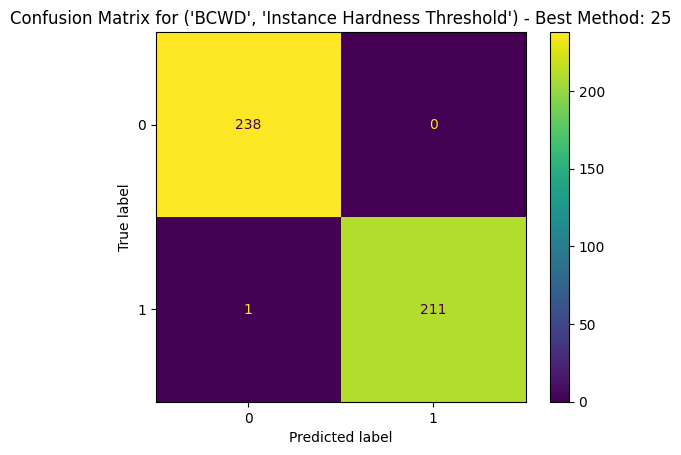

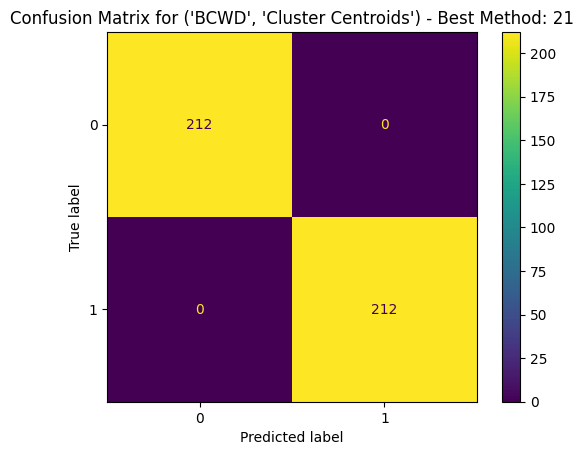

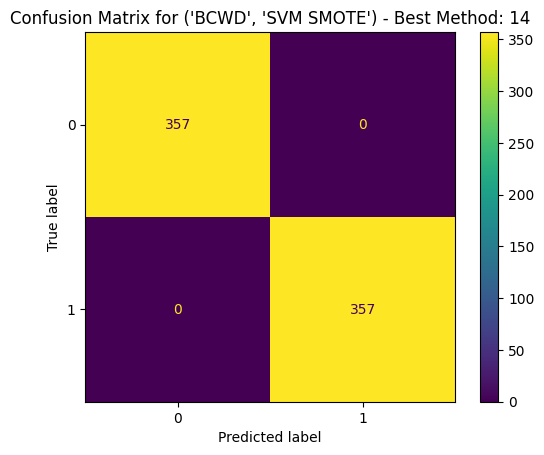

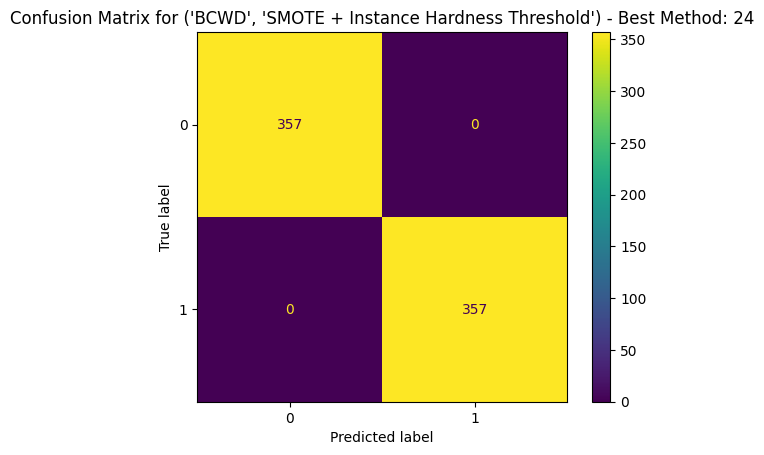

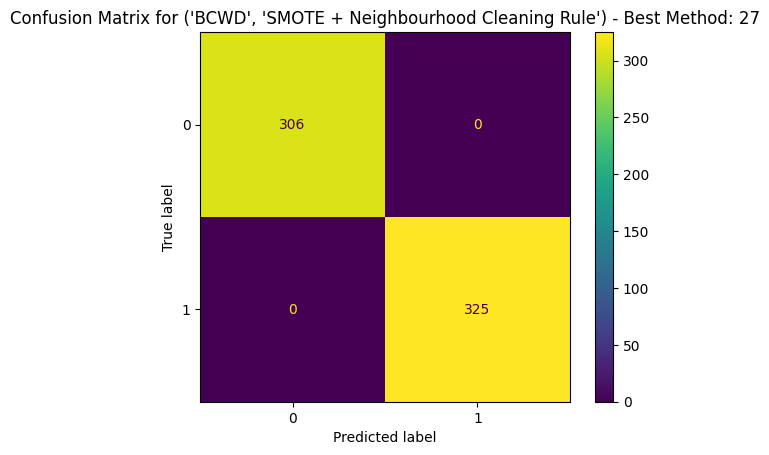

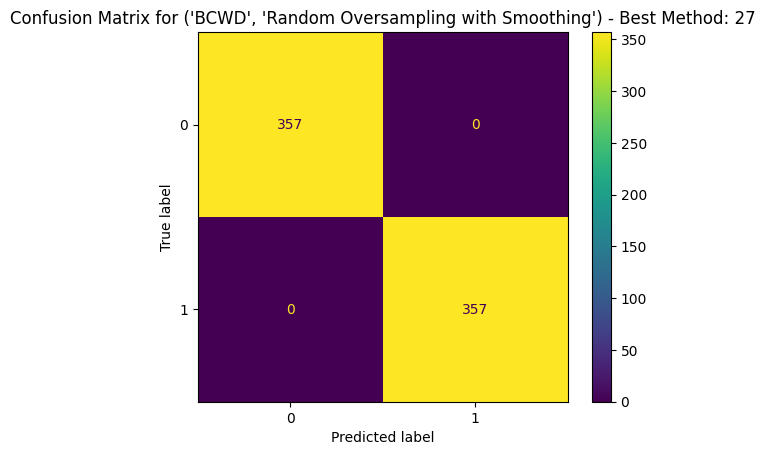

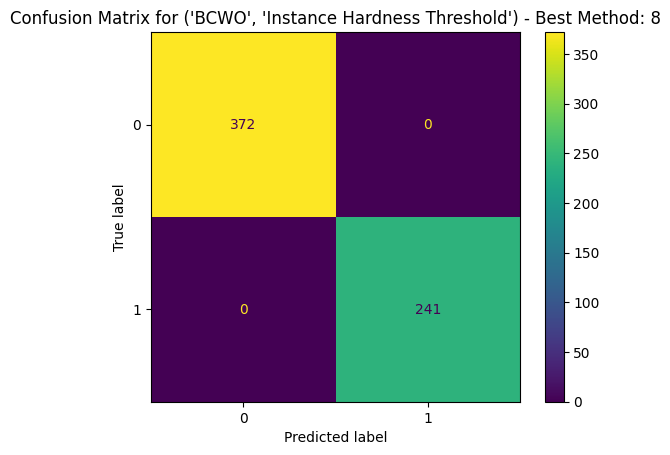

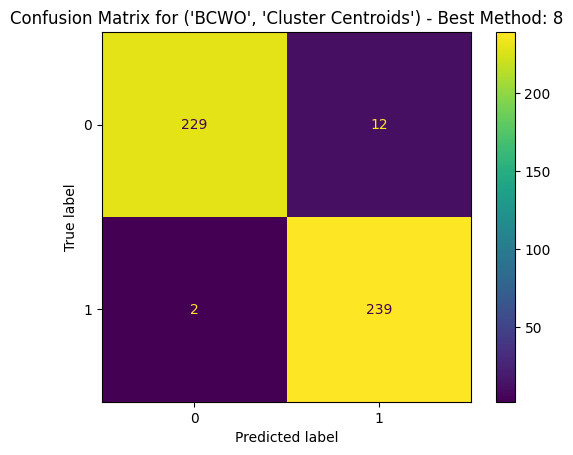

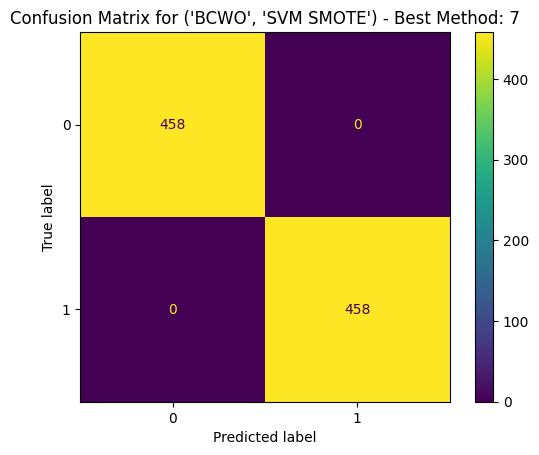

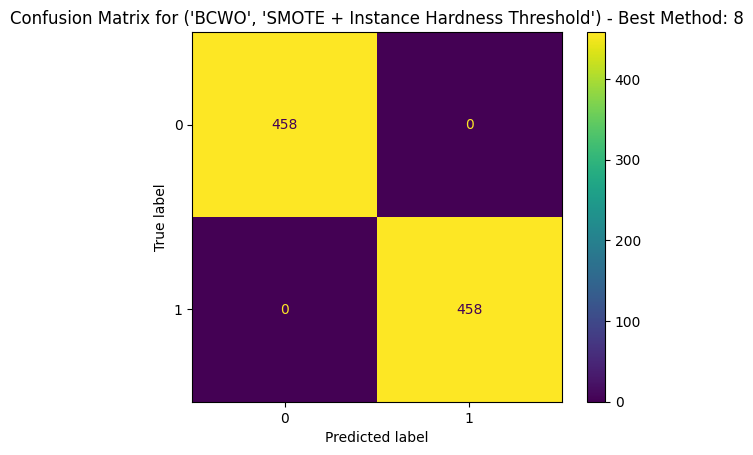

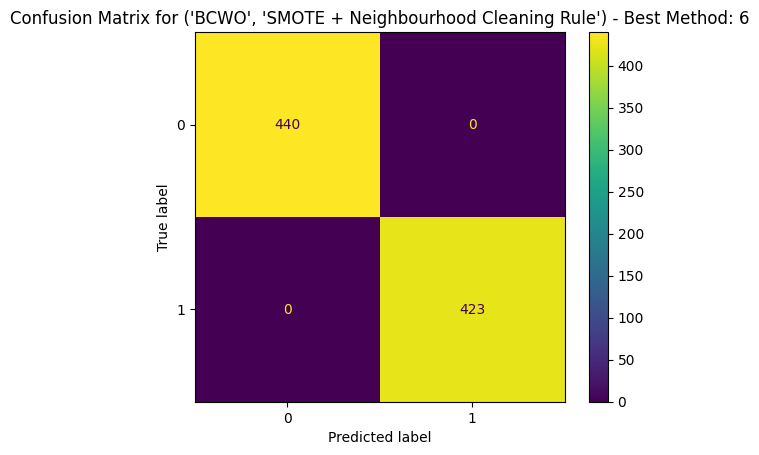

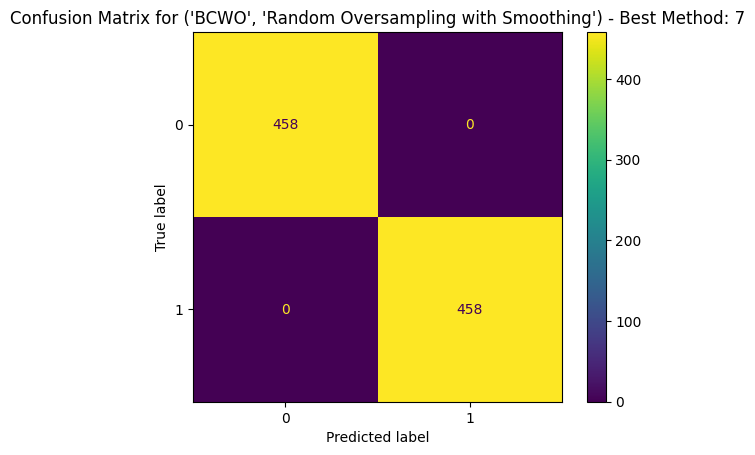

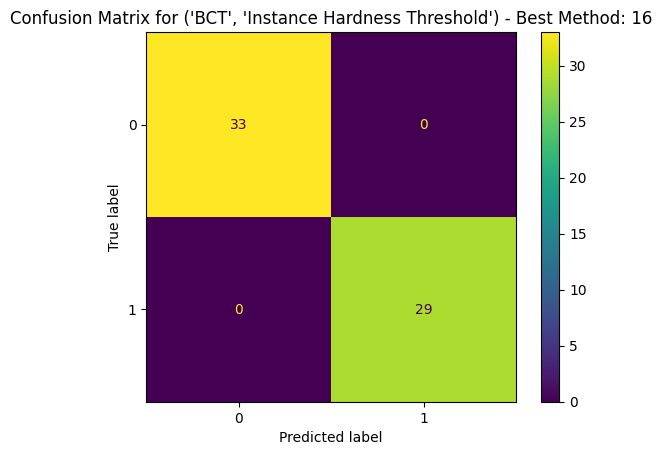

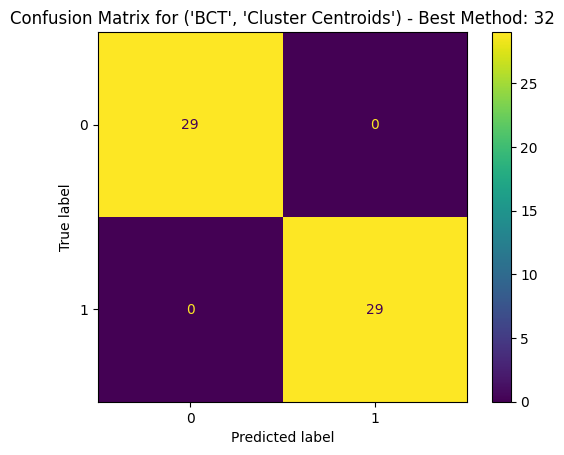

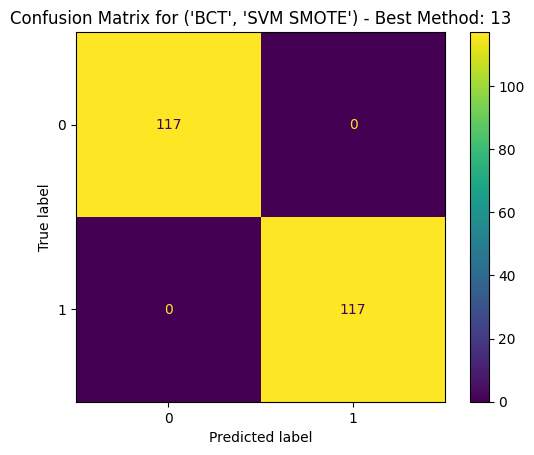

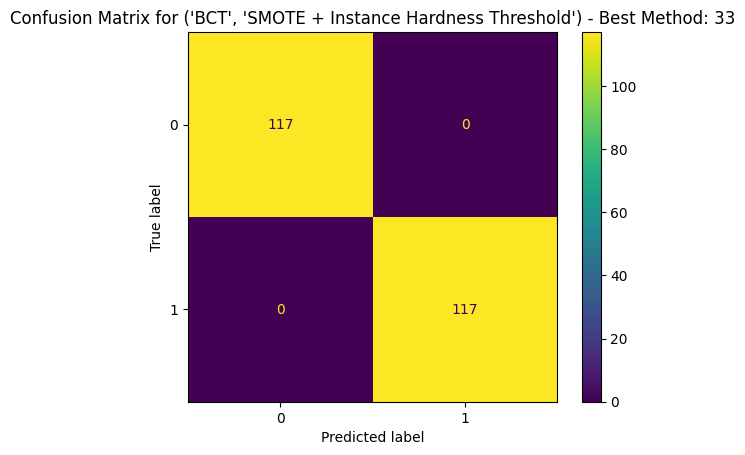

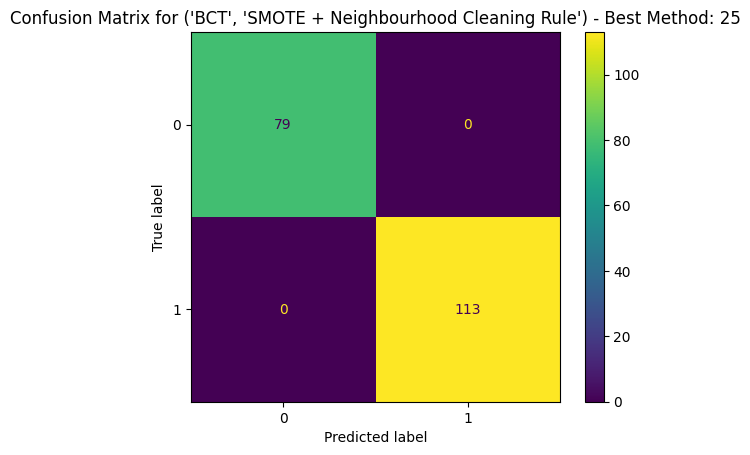

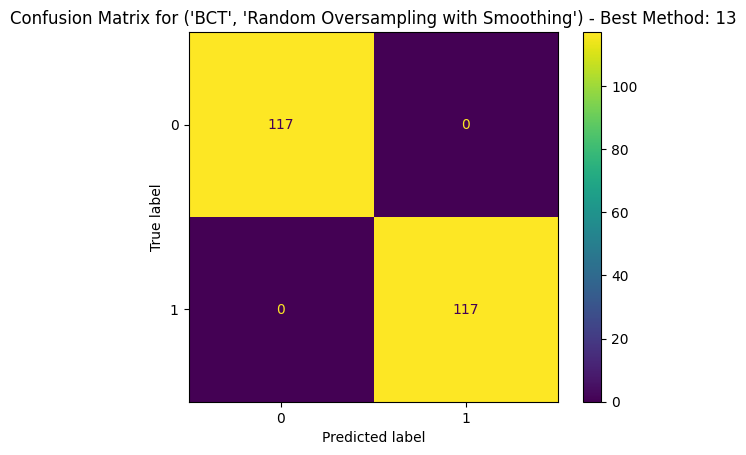

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.under_sampling import InstanceHardnessThreshold, ClusterCentroids
from imblearn.over_sampling import SVMSMOTE, SMOTE, RandomOverSampler
from imblearn.under_sampling import NeighbourhoodCleaningRule
import matplotlib.pyplot as plt
from scipy.stats import randint
import warnings

warnings.filterwarnings('ignore')

def ensure_dataframe(X, y):
    """
    Ensure that the input features (X) and target (y) are in pandas DataFrame or Series format.

    Parameters:
        X (array-like or DataFrame): Input feature data.
        y (array-like, DataFrame, or Series): Target labels.

    Returns:
        X (DataFrame): Feature data in DataFrame format.
        y (Series): Target data in Series format.
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    if not isinstance(y, pd.Series):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]  # Extract the first column if y is a DataFrame
        else:
            y = pd.Series(y)
    return X, y


X_bcwd, y_bcwd = ensure_dataframe(X_bcwd, y_bcwd)
X_bcwo, y_bcwo = ensure_dataframe(X_bcwo, y_bcwo)

# Impute missing values for the BCWO dataset using KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_bcwo = pd.DataFrame(imputer.fit_transform(X_bcwo), columns=X_bcwo.columns)

def specificity_score(y_true, y_pred):
    """
    Calculate specificity (true negative rate) from the confusion matrix.

    Parameters:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        float: Specificity score.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

def geometric_mean_score(y_true, y_pred):
    """
    Calculate the geometric mean of sensitivity (recall) and specificity.

    Parameters:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        float: Geometric mean score.
    """
    sensitivity = recall_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

# Create custom scoring functions for use in model evaluation
specificity = make_scorer(specificity_score)
g_mean = make_scorer(geometric_mean_score, greater_is_better=True)
f1 = make_scorer(f1_score)

def smote_instance_hardness_threshold(X, y):
    """
    Apply SMOTE followed by Instance Hardness Threshold for resampling.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.

    Returns:
        X_res (DataFrame or ndarray): Resampled input features.
        y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101, k_neighbors=5)
    iht = InstanceHardnessThreshold(sampling_strategy='all', random_state=101)
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = iht.fit_resample(X_res, y_res)
    return X_res, y_res

def smote_neighbourhood_cleaning_rule(X, y):
    """
    Apply SMOTE followed by Neighbourhood Cleaning Rule for resampling.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.

    Returns:
        X_res (DataFrame or ndarray): Resampled input features.
        y_res (Series or ndarray): Resampled target labels.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101)
    ncr = NeighbourhoodCleaningRule(sampling_strategy='all')
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = ncr.fit_resample(X_res, y_res)
    return X_res, y_res


n_features_values = {
    'BCWD': randint(10, 30),
    'BCWO': randint(3, 9),
    'BCT': randint(10, 38)
}

def build_and_evaluate_model(X, y, sampling_method=None, feature_selection=True):
    """
    Build and evaluate a Gradient Boosting model with feature selection using RandomizedSearchCV.

    Parameters:
        X (DataFrame or ndarray): Input features.
        y (Series or ndarray): Target labels.
        sampling_method (function or None): Resampling method to handle class imbalance.
        feature_selection (bool): Whether to perform feature selection or not.

    Returns:
        cv_results (dict): Cross-validation results.
        best_params (dict): Best hyperparameters found by RandomizedSearchCV.
        best_estimator (Pipeline): The best model pipeline.
        X_resampled (DataFrame or ndarray): Resampled input features.
        y_resampled (Series or ndarray): Resampled target labels.
        num_features_selected (int): Number of features selected by RFE or total features if no feature selection.
    """
    scaler = StandardScaler()
    gb_model = GradientBoostingClassifier()

    # Define the feature selection step if enabled
    if feature_selection:
        rfe = RFE(estimator=gb_model)
        pipeline_steps = [('scaler', scaler), ('rfe', rfe), ('gb', gb_model)]
        param_dist = {
            'rfe__n_features_to_select': n_features_values[dataset_name],
            'gb__n_estimators': randint(50, 200),
            'gb__learning_rate': [0.01, 0.1, 0.2, 0.3],
            'gb__max_depth': randint(3, 5)
        }
    else:
        pipeline_steps = [('scaler', scaler), ('gb', gb_model)]
        param_dist = {
            'gb__n_estimators': randint(50, 200),
            'gb__learning_rate': [0.01, 0.1, 0.2, 0.3],
            'gb__max_depth': randint(3, 5)
        }

    pipeline = Pipeline(pipeline_steps)

    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)


    random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=50, cv=stratified_kfold, scoring=g_mean, n_jobs=2, random_state=101)

    # Apply resampling method if provided
    if sampling_method:
        if callable(sampling_method):
            X_resampled, y_resampled = sampling_method(X, y)
        else:
            X_resampled, y_resampled = sampling_method.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    random_search.fit(X_resampled, y_resampled)
    best_params = random_search.best_params_


    cv_results = cross_validate(random_search.best_estimator_, X_resampled, y_resampled, cv=stratified_kfold, scoring={
        'accuracy': 'accuracy',
        'sensitivity': 'recall',
        'specificity': specificity,
        'g_mean': g_mean,
        'f1': f1
    }, n_jobs=2, return_train_score=False)

    num_features_selected = random_search.best_estimator_.named_steps['rfe'].n_features_ if feature_selection else X.shape[1]

    return cv_results, best_params, random_search.best_estimator_, X_resampled, y_resampled, num_features_selected


sampling_methods = {
    'Instance Hardness Threshold': InstanceHardnessThreshold(random_state=101),
    'Cluster Centroids': ClusterCentroids(random_state=101),
    'SVM SMOTE': SVMSMOTE(random_state=101),
    'SMOTE + Instance Hardness Threshold': smote_instance_hardness_threshold,
    'SMOTE + Neighbourhood Cleaning Rule': smote_neighbourhood_cleaning_rule,
    'Random Oversampling with Smoothing': RandomOverSampler(sampling_strategy='auto', random_state=101)
}


datasets = {
    'BCWD': (X_bcwd, y_bcwd),
    'BCWO': (X_bcwo, y_bcwo),
    'BCT': (X_bct, y_bct)
}

results = []
best_models = {}

for dataset_name, (X, y) in datasets.items():
    for method_name, sampling_method in sampling_methods.items():
        best_gmean = 0
        best_cv_results = None
        best_best_params = None
        best_n_features = None

        # Iterate over different sampling methods and feature selection
        cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
            X, y, sampling_method)

        # Update the best results if the current model has a better G-Mean
        if np.mean(cv_results['test_g_mean']) > best_gmean:
            best_gmean = np.mean(cv_results['test_g_mean'])
            best_cv_results = cv_results
            best_best_params = best_params
            best_n_features = num_features_selected
            best_models[(dataset_name, method_name)] = (best_estimator, X_resampled, y_resampled, best_n_features)

        if best_cv_results is not None:
            result = {
                'Dataset': dataset_name,
                'Method': method_name,
                'n_features': best_n_features,
                'Accuracy': np.mean(best_cv_results['test_accuracy']),
                'Sensitivity': np.mean(best_cv_results['test_sensitivity']),
                'Specificity': np.mean(best_cv_results['test_specificity']),
                'G-Mean': np.mean(best_cv_results['test_g_mean']),
                'F1 Score': np.mean(best_cv_results['test_f1']),
                'Best Params': best_best_params,
                'Num Features Selected': best_n_features
            }
            results.append(result)

    # Evaluate the dataset without any resampling method and with feature selection
    best_no_resampling_result = None
    best_no_resampling_gmean = 0
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
        X, y, feature_selection=True)

    if np.mean(cv_results['test_g_mean']) > best_no_resampling_gmean:
        best_no_resampling_gmean = np.mean(cv_results['test_g_mean'])
        best_no_resampling_result = {
            'Dataset': dataset_name,
            'Method': 'No Resampling',
            'n_features': num_features_selected,
            'Accuracy': np.mean(cv_results['test_accuracy']),
            'Sensitivity': np.mean(cv_results['test_sensitivity']),
            'Specificity': np.mean(cv_results['test_specificity']),
            'G-Mean': np.mean(cv_results['test_g_mean']),
            'F1 Score': np.mean(cv_results['test_f1']),
            'Best Params': best_params,
            'Num Features Selected': num_features_selected
        }

    if best_no_resampling_result is not None:
        results.append(best_no_resampling_result)

    # Evaluate the dataset without any resampling method and without feature selection (only hyperparameter tuning)
    cv_results, best_params, best_estimator, X_resampled, y_resampled, num_features_selected = build_and_evaluate_model(
        X, y, feature_selection=False)

    result_no_resampling_no_fs = {
        'Dataset': dataset_name,
        'Method': 'No Resampling + No Feature Selection',
        'n_features': num_features_selected,
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Sensitivity': np.mean(cv_results['test_sensitivity']),
        'Specificity': np.mean(cv_results['test_specificity']),
        'G-Mean': np.mean(cv_results['test_g_mean']),
        'F1 Score': np.mean(cv_results['test_f1']),
        'Best Params': best_params,
        'Num Features Selected': num_features_selected
    }
    results.append(result_no_resampling_no_fs)

# Identify the best model for each dataset based on G-Mean
best_dataset_results = []
for dataset_name in datasets.keys():
    dataset_results = [r for r in results if r['Dataset'] == dataset_name]
    best_method_result = max(dataset_results, key=lambda x: x['G-Mean'])
    best_dataset_results.append(best_method_result)

    print(f"Best model for {dataset_name} is {best_method_result['Method']} with {best_method_result['n_features']} features")


results_gbc = pd.DataFrame(results)
best_results_gbc = pd.DataFrame(best_dataset_results)

print(results_gbc.round(4))
print(best_results_gbc.round(4))

results_gbc.to_csv('results_gbc.csv', index=False)
best_results_gbc.to_csv('best_results_gbc.csv', index=False)

# Plot confusion matrix for the best models
for dataset_name, (model, X_resampled, y_resampled, best_method) in best_models.items():
    y_pred = model.predict(X_resampled)
    cm = confusion_matrix(y_resampled, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix for {dataset_name} - Best Method: {best_method}")
    plt.show()


In [ ]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 5.6 MB/s eta 0:00:00


**ANN with all sampling approaches**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix, make_scorer, f1_score, ConfusionMatrixDisplay
from imblearn.under_sampling import InstanceHardnessThreshold, ClusterCentroids
from imblearn.over_sampling import SVMSMOTE, SMOTE, RandomOverSampler
from imblearn.under_sampling import NeighbourhoodCleaningRule
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK
import warnings
import matplotlib.pyplot as plt

from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

# GPU configuration to prevent TensorFlow from consuming all memory
config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

warnings.filterwarnings('ignore')

def ensure_dataframe(X, y):
    """
    Ensures that the features and target are in pandas DataFrame or Series format.

    Parameters:
    - X: Features, can be numpy array, list, or DataFrame.
    - y: Target, can be numpy array, list, Series, or DataFrame.

    Returns:
    - X: Features as a DataFrame.
    - y: Target as a Series.
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    if not isinstance(y, pd.Series):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]  # Extract the first column if y is a DataFrame
        else:
            y = pd.Series(y)
    return X, y


X_bcwd, y_bcwd = ensure_dataframe(X_bcwd, y_bcwd)
X_bcwo, y_bcwo = ensure_dataframe(X_bcwo, y_bcwo)

# Impute missing values for BCWO dataset using KNNImputer
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_bcwo = pd.DataFrame(imputer.fit_transform(X_bcwo), columns=X_bcwo.columns)

def specificity_score(y_true, y_pred):
    """
    Computes the specificity (true negative rate) from true and predicted labels.

    Parameters:
    - y_true: Array of true labels.
    - y_pred: Array of predicted labels.

    Returns:
    - specificity: The specificity (TN / (TN + FP)).
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

def geometric_mean_custom_score(y_true, y_pred):
    """
    Computes the geometric mean of sensitivity and specificity.

    Parameters:
    - y_true: Array of true labels.
    - y_pred: Array of predicted labels.

    Returns:
    - gmean: The geometric mean of sensitivity and specificity.
    """
    sensitivity = recall_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

def smote_instance_hardness_threshold(X, y):
    """
    Applies SMOTE followed by Instance Hardness Threshold resampling.

    Parameters:
    - X: Features as a DataFrame or array.
    - y: Target as a Series or array.

    Returns:
    - X_res: Resampled features.
    - y_res: Resampled target.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101, k_neighbors=5)
    iht = InstanceHardnessThreshold(sampling_strategy='all', random_state=101)
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = iht.fit_resample(X_res, y_res)
    return X_res, y_res

def smote_neighbourhood_cleaning_rule(X, y):
    """
    Applies SMOTE followed by Neighbourhood Cleaning Rule resampling.

    Parameters:
    - X: Features as a DataFrame or array.
    - y: Target as a Series or array.

    Returns:
    - X_res: Resampled features.
    - y_res: Resampled target.
    """
    sm = SMOTE(sampling_strategy='auto', random_state=101)
    ncr = NeighbourhoodCleaningRule(sampling_strategy='all')
    X_res, y_res = sm.fit_resample(X, y)
    X_res, y_res = ncr.fit_resample(X_res, y_res)
    return X_res, y_res

def specificity(y_true, y_pred):
    """
    Computes the specificity (true negative rate) in a TensorFlow/Keras environment.

    Parameters:
    - y_true: Tensor of true labels.
    - y_pred: Tensor of predicted labels.

    Returns:
    - specificity: Tensor representing specificity.
    """
    y_true = tf.cast(y_true, tf.float32)
    true_negatives = tf.reduce_sum(tf.round(tf.clip_by_value((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = tf.reduce_sum(tf.round(tf.clip_by_value(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + tf.keras.backend.epsilon())

def gmean(y_true, y_pred):
    """
    Computes the geometric mean of sensitivity and specificity in a TensorFlow/Keras environment.

    Parameters:
    - y_true: Tensor of true labels.
    - y_pred: Tensor of predicted labels.

    Returns:
    - gmean: Tensor representing the geometric mean of sensitivity and specificity.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    true_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    possible_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true, 0, 1)))
    sensitivity = true_positives / (possible_positives + tf.keras.backend.epsilon())

    spec = specificity(y_true, y_pred)
    return tf.sqrt(sensitivity * spec)

def create_ann(hidden_layer_sizes, activation, optimizer, dropout_rate, input_dim, learning_rate):
    """
    Creates and compiles an Artificial Neural Network (ANN) model with specified hyperparameters.

    Parameters:
    - hidden_layer_sizes: Tuple of integers representing the number of units in each hidden layer.
    - activation: String representing the activation function (e.g., 'relu', 'tanh').
    - optimizer: String representing the optimizer to use (e.g., 'adam', 'sgd').
    - dropout_rate: Float representing the dropout rate to apply after each layer.
    - input_dim: Integer representing the number of input features.
    - learning_rate: Float representing the learning rate for the optimizer.

    Returns:
    - model: Compiled Keras Sequential model.
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(hidden_layer_sizes[0], activation=activation, input_shape=(input_dim,), kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_rate))

    for units in hidden_layer_sizes[1:]:
        model.add(tf.keras.layers.Dense(units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    optimizer_instance = tf.keras.optimizers.get(optimizer)
    optimizer_instance.learning_rate = learning_rate

    model.compile(optimizer=optimizer_instance,
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='sensitivity'), specificity, gmean])

    return model

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', [(256, 128, 64, 32), (512, 256, 128), (128, 64, 32), (64, 32)]),
    'activation': hp.choice('activation', ['relu', 'tanh']),
    'optimizer': hp.choice('optimizer', ['adam', 'sgd']),
    'dropout_rate': hp.uniform('dropout_rate', 0.3, 0.7),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.0001), np.log(0.01)),
}


sampling_methods = {
    'No Resampling': None,
    'Instance Hardness Threshold': InstanceHardnessThreshold(random_state=101),
    'Cluster Centroids': ClusterCentroids(random_state=101),
    'SVM SMOTE': SVMSMOTE(random_state=101),
    'SMOTE + Instance Hardness Threshold': smote_instance_hardness_threshold,
    'SMOTE + Neighbourhood Cleaning Rule': smote_neighbourhood_cleaning_rule,
    'Random Oversampling with Smoothing': RandomOverSampler(sampling_strategy='auto', shrinkage=2, random_state=101)
}

datasets = {
    'BCWD': (X_bcwd, y_bcwd),
    'BCWO': (X_bcwo, y_bcwo),
    'BCT': (X_bct, y_bct)
}

def boruta_feature_selection(X, y):
    """
    Performs feature selection using the Boruta algorithm with a Random Forest model.

    Parameters:
    - X: Features as a DataFrame.
    - y: Target as a Series.

    Returns:
    - X_selected: DataFrame with selected features.
    """
    model_rf = RandomForestClassifier(n_jobs=-1, max_depth=5, random_state=101)
    feat_selector = BorutaPy(model_rf, n_estimators='auto', verbose=0, random_state=101)
    feat_selector.fit(X.values, y.values)
    X_selected = pd.DataFrame(feat_selector.transform(X.values), columns=X.columns[feat_selector.support_])
    return X_selected

def objective(params, X, y, sampling_method, feature_selection=True):
    """
    Objective function for Hyperopt optimization, including data resampling, feature selection, and ANN training.

    Parameters:
    - params: Dictionary of hyperparameters for the ANN model.
    - X: Features as a DataFrame.
    - y: Target as a Series.
    - sampling_method: Resampling method to apply, or None for no resampling.
    - feature_selection: Whether to apply Boruta feature selection.

    Returns:
    - Dictionary with loss value (negative G-mean), status, metrics, and number of selected features.
    """
    hidden_layer_sizes = params['hidden_layer_sizes']
    activation = params['activation']
    optimizer = params['optimizer']
    dropout_rate = params['dropout_rate']
    learning_rate = params['learning_rate']


    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply resampling if a method is specified
    if sampling_method is None:  # No resampling
        X_resampled, y_resampled = X_scaled, y
    elif callable(sampling_method):
        X_resampled, y_resampled = sampling_method(X_scaled, y)
    else:
        X_resampled, y_resampled = sampling_method.fit_resample(X_scaled, y)

    # Apply Boruta feature selection
    if feature_selection:
        X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
        X_selected = boruta_feature_selection(X_resampled_df, pd.Series(y_resampled))
    else:
        X_selected = pd.DataFrame(X_resampled, columns=X.columns)

    num_features_selected = X_selected.shape[1]  # Calculate the number of selected features


    model = create_ann(hidden_layer_sizes, activation, optimizer, dropout_rate, X_selected.shape[1], learning_rate)


    early_stopping = EarlyStopping(monitor='val_gmean', patience=20, restore_best_weights=True, mode='max')


    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)
    metrics = {'accuracy': [], 'sensitivity': [], 'specificity': [], 'gmean': [], 'f1': []}

    for train_idx, test_idx in cv.split(X_selected.values, y_resampled):
        X_train, X_test = X_selected.values[train_idx], X_selected.values[test_idx]
        y_train, y_test = y_resampled[train_idx], y_resampled[test_idx]

        model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32,
                  callbacks=[early_stopping], verbose=0)

        # Predict and compute metrics
        predictions = (model.predict(X_test) > 0.5).astype(int)
        accuracy = accuracy_score(y_test, predictions)
        sensitivity = recall_score(y_test, predictions)
        spec = specificity_score(y_test, predictions)
        g_mean = geometric_mean_custom_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        metrics['accuracy'].append(accuracy)
        metrics['sensitivity'].append(sensitivity)
        metrics['specificity'].append(spec)
        metrics['gmean'].append(g_mean)
        metrics['f1'].append(f1)

    # Average metrics
    avg_metrics = {k: np.mean(v) for k, v in metrics.items()}

    return {'loss': -avg_metrics['gmean'], 'status': STATUS_OK, 'metrics': avg_metrics, 'num_features_selected': num_features_selected}


results = []
best_models = {}

for dataset_name, (X, y) in datasets.items():
    for method_name, sampling_method in sampling_methods.items():
        if method_name == "No Resampling":
            method_name = f"{dataset_name} No Resampling"

        trials = Trials()
        best_params = fmin(fn=lambda params: objective(params, X, y, sampling_method),
                           space=space,
                           algo=tpe.suggest,
                           max_evals=10,
                           trials=trials,
                           rstate=np.random.default_rng(101))

        # Store results
        trial_result = trials.best_trial['result']['metrics']
        num_features_selected = trials.best_trial['result']['num_features_selected']
        trial_result.update({
            'Dataset': dataset_name,
            'Method': method_name,
            'Features Selected': num_features_selected
        })
        results.append(trial_result)

        # Store the best model for confusion matrix plotting
        if (dataset_name, method_name) not in best_models or trial_result['gmean'] > best_models[(dataset_name, method_name)]['gmean']:
            best_models[(dataset_name, method_name)] = {
                'model': trials.best_trial['result'],
                'X': X,
                'y': y,
                'sampling_method': sampling_method,
                'feature_selection': True
            }

    # Add No Sampling + No Feature Selection case
    trials = Trials()
    best_params = fmin(fn=lambda params: objective(params, X, y, sampling_method=None, feature_selection=False),
                       space=space,
                       algo=tpe.suggest,
                       max_evals= 10,
                       trials=trials,
                       rstate=np.random.default_rng(101))

    trial_result = trials.best_trial['result']['metrics']
    trial_result.update({
        'Dataset': dataset_name,
        'Method': f"{dataset_name} No Sampling + No Feature Selection",
        'Features Selected': X.shape[1]  # No features were removed
    })
    results.append(trial_result)

    # Store the best model for confusion matrix plotting
    if (dataset_name, "No Sampling + No Feature Selection") not in best_models or trial_result['gmean'] > best_models[(dataset_name, "No Sampling + No Feature Selection")]['gmean']:
        best_models[(dataset_name, "No Sampling + No Feature Selection")] = {
            'model': trials.best_trial['result'],
            'X': X,
            'y': y,
            'sampling_method': None,
            'feature_selection': False
        }

# Convert the results to a DataFrame
results_ann = pd.DataFrame(results).sort_values(by=['Dataset', 'Method'])

# Save the results to a CSV file
results_ann.to_csv('results_ann.csv', index=False)

# Print the results
print(results_ann)



# Close the TensorFlow session
session.close()


Streaming output truncated to the last 5000 lines.

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━